In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
import os
from scipy.stats import zscore

## BMI 

Original dataset shape: (1439696, 216)
Subset shape before NaN handling: (1439696, 8)
Subset shape after NaN replacement: (1439696, 8)
Subset shape after index reset: (1439696, 8)

Summary Statistics for Selected Columns:
              _BMI5      _BMI5CAT       _RFBMI5       WEIGHT2         WTKG3  \
count  1.348949e+06  1.348949e+06  1.439696e+06  1.366618e+06  1.366602e+06   
mean   2.783243e+03  2.919372e+00  2.112488e+00  1.919078e+02  8.010709e+03   
std    6.265441e+02  8.267934e-01  1.845171e+00  3.715695e+02  2.052155e+03   
min    1.202000e+03  1.000000e+00  1.000000e+00  5.000000e+01  2.268000e+03   
25%    2.367000e+03  2.000000e+00  1.000000e+00  1.450000e+02  6.577000e+03   
50%    2.663000e+03  3.000000e+00  2.000000e+00  1.700000e+02  7.711000e+03   
75%    3.079000e+03  4.000000e+00  2.000000e+00  2.000000e+02  9.072000e+03   
max    9.995000e+03  4.000000e+00  9.000000e+00  9.501000e+03  2.903000e+04   

            HEIGHT3          HTM4         HTIN4  
count  1.409645e

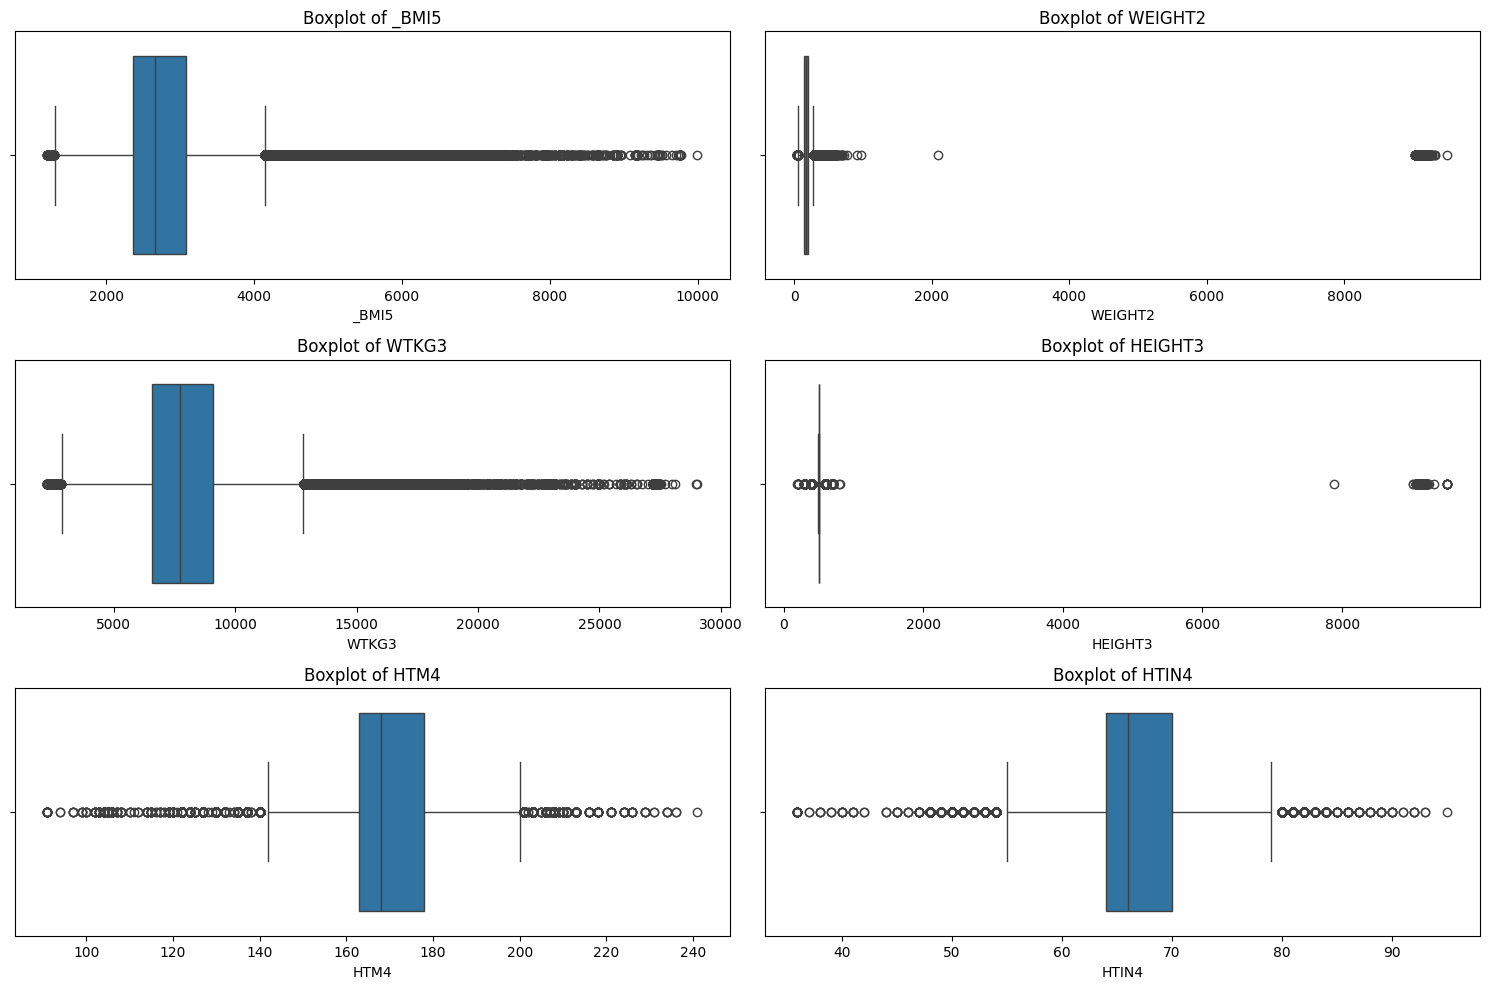

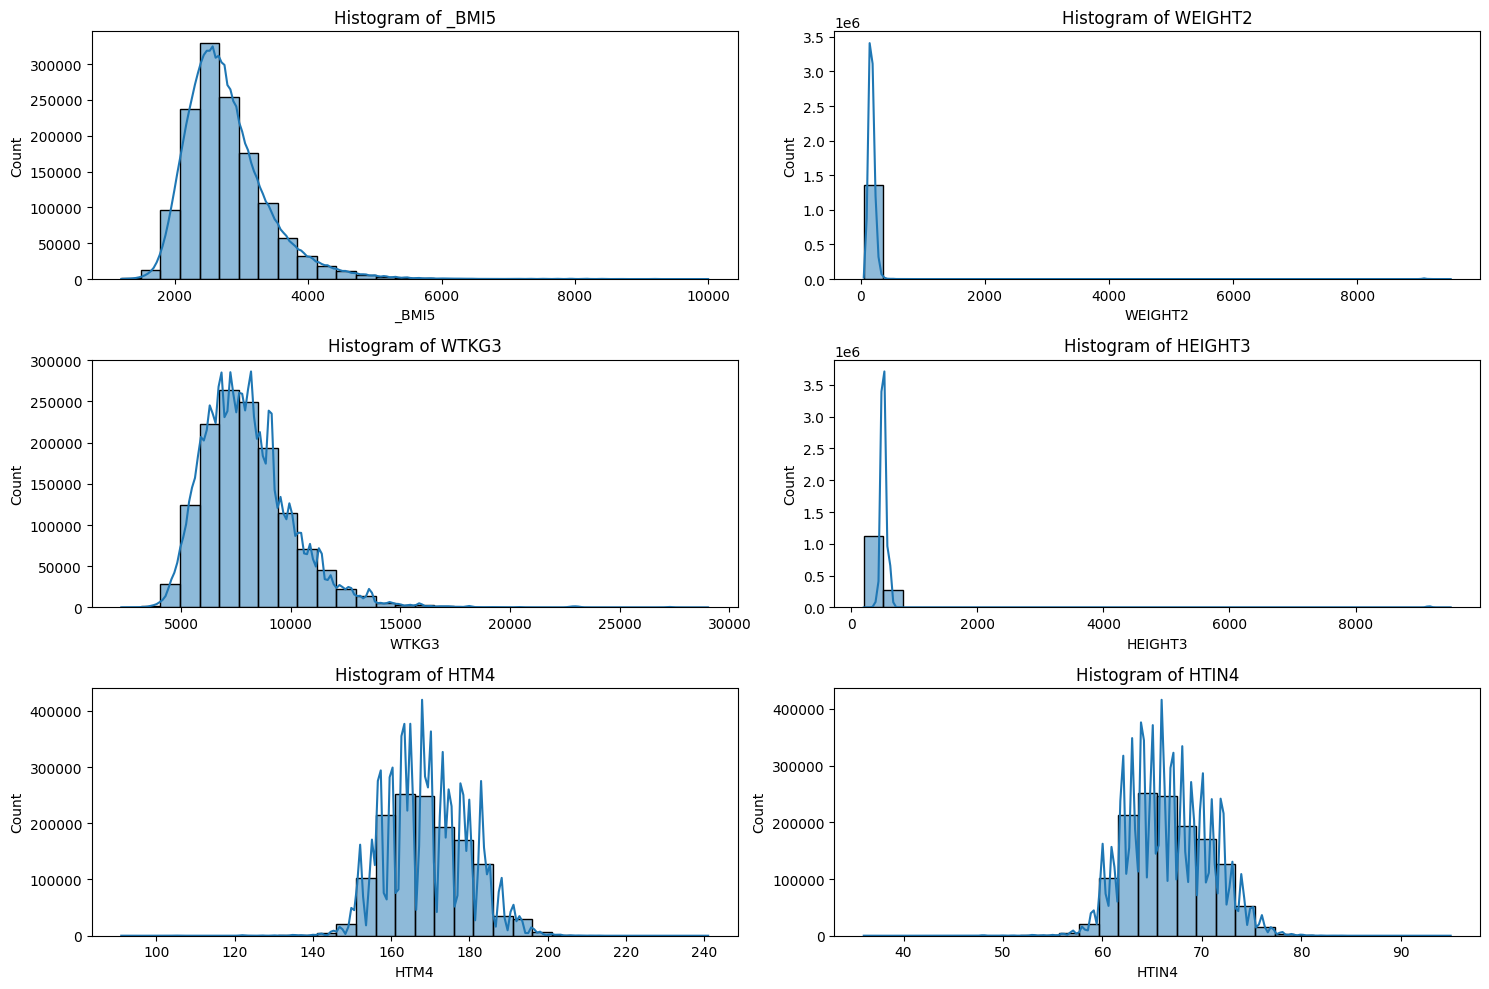

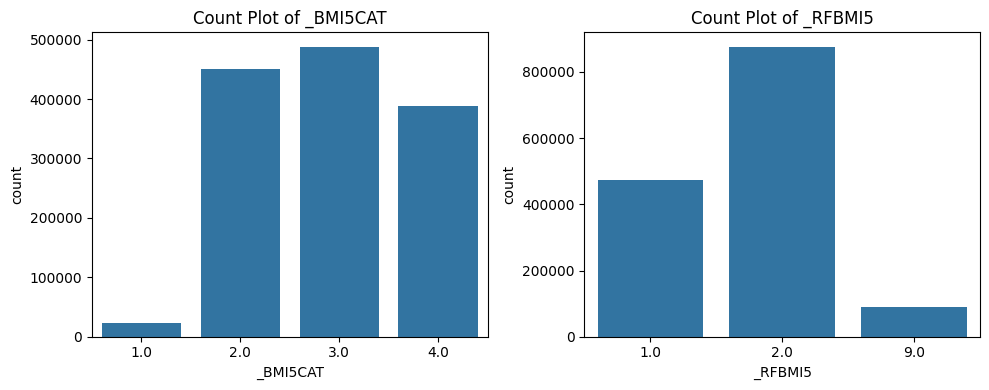

In [2]:
df_cleaned = pd.read_csv('../data/raw/Behavioral_Risk_Factor_Surveillance_2011_2013_2015.csv')
print(f"Original dataset shape: {df_cleaned.shape}")

# Columns to analyze for outliers
columns = ['_BMI5', '_BMI5CAT', '_RFBMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4']

# Subset the dataset to these columns
df_subset = df_cleaned[columns].copy()
print(f"Subset shape before NaN handling: {df_subset.shape}")

# Step 1: Handle BRFSS-specific codes (e.g., 7777, 9999 for "don't know"/"refused")
# Replace common BRFSS codes with NaN for numerical columns
num_columns = ['_BMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4']
df_subset[num_columns] = df_subset[num_columns].replace([777, 7777, 999, 9999], np.nan)
print(f"Subset shape after NaN replacement: {df_subset.shape}")

# Reset index to avoid misalignment
df_subset = df_subset.reset_index(drop=True)
print(f"Subset shape after index reset: {df_subset.shape}")

# Step 2: Summary statistics
print("\nSummary Statistics for Selected Columns:")
print(df_subset.describe(include='all'))

# Step 3: Detect outliers using IQR and Z-score
def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method."""
    # Drop NaNs for this column to avoid issues in quantile calculation
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Create boolean mask for outliers
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    # Apply mask, ensuring NaNs are preserved
    outliers = data.loc[mask, column]
    return len(outliers), lower_bound, upper_bound

def detect_outliers_zscore(data, column, threshold=3):
    """Detect outliers using Z-score method."""
    valid_data = data[column].dropna()
    z_scores = zscore(valid_data)
    # Create mask for valid data
    mask = np.abs(z_scores) > threshold
    outliers = valid_data[mask]
    return len(outliers)

# Print outlier counts
print("\nOutlier Counts (IQR and Z-score):")
for col in num_columns:
    if df_subset[col].notna().sum() > 0:  # Check if column has non-null values
        iqr_count, lower, upper = detect_outliers_iqr(df_subset, col)
        zscore_count = detect_outliers_zscore(df_subset, col)
        print(f"{col}:")
        print(f"  IQR Outliers: {iqr_count} (Lower: {lower:.2f}, Upper: {upper:.2f})")
        print(f"  Z-score Outliers (threshold=3): {zscore_count}")

# Step 4: Handle categorical columns (_BMI5CAT, _RFBMI5)
# Check unique values and their frequencies
for col in ['_BMI5CAT', '_RFBMI5']:
    print(f"\nUnique values in {col}:")
    print(df_subset[col].value_counts(dropna=False))

# Step 5: Visualize outliers with boxplots and histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_columns, 1):
    if df_subset[col].notna().sum() > 0:
        plt.subplot(3, 2, i)
        sns.boxplot(x=df_subset[col])
        plt.title(f'Boxplot of {col}')
        plt.xlabel(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_columns, 1):
    if df_subset[col].notna().sum() > 0:
        plt.subplot(3, 2, i)
        sns.histplot(df_subset[col].dropna(), bins=30, kde=True)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
plt.tight_layout()
plt.show()

# Step 6: Visualize categorical columns
plt.figure(figsize=(10, 4))
for i, col in enumerate(['_BMI5CAT', '_RFBMI5'], 1):
    plt.subplot(1, 2, i)
    sns.countplot(x=df_subset[col].dropna())
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

Dataset shape: (1439696, 216)

Consistency Check:
WTKG3/WEIGHT2_kg ratio (should be ~1):
count    1.365536e+06
mean     9.999983e-01
std      3.911707e-05
min      9.998165e-01
25%      9.999641e-01
50%      9.999976e-01
75%      1.000018e+00
max      1.000165e+00
Name: WTKG3_check, dtype: float64
HTM4/HEIGHT3_cm ratio (should be ~1):
count    1.409598e+06
mean     1.322044e-01
std      5.316840e-02
min      1.194226e-01
25%      1.231295e-01
50%      1.286349e-01
75%      1.340753e-01
max      1.000000e+00
Name: HTM4_check, dtype: float64

Descriptive Statistics for Continuous Columns:
              _BMI5         WTKG3          HTM4         HTIN4       WEIGHT2  \
count  1.348949e+06  1.366602e+06  1.409598e+06  1.404392e+06  1.366618e+06   
mean   2.783244e+03  8.010708e+03  1.692521e+02  6.664160e+01  1.919078e+02   
std    6.265441e+02  2.052155e+03  1.049941e+01  4.108779e+00  3.715695e+02   
min    1.202000e+03  2.268000e+03  9.100000e+01  3.600000e+01  5.000000e+01   
25%    2.36

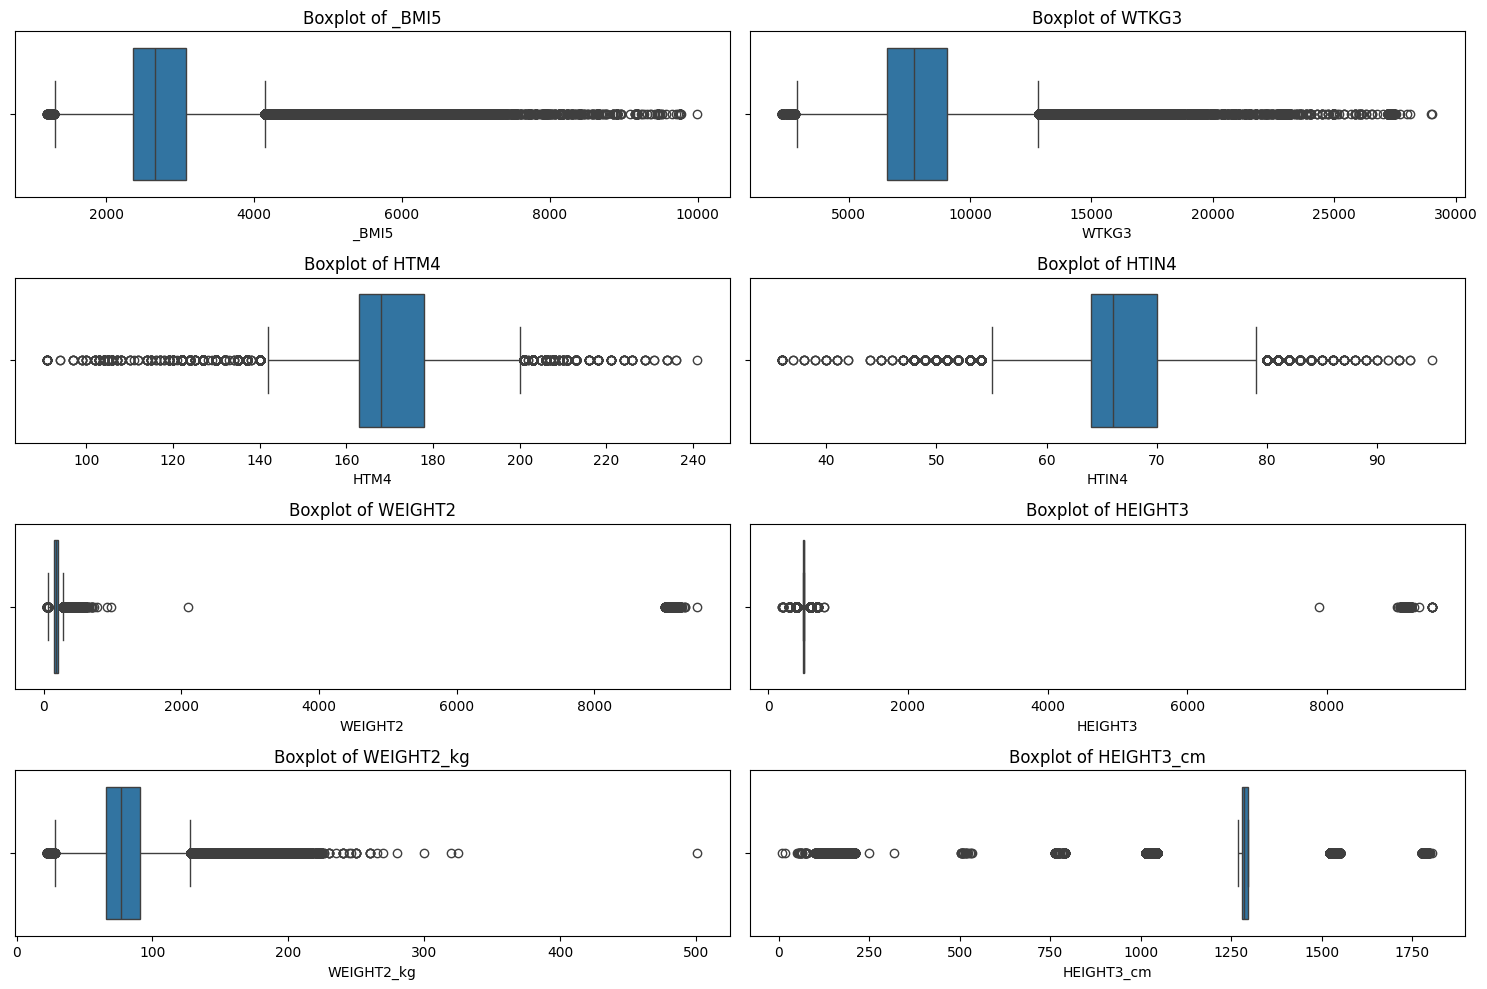

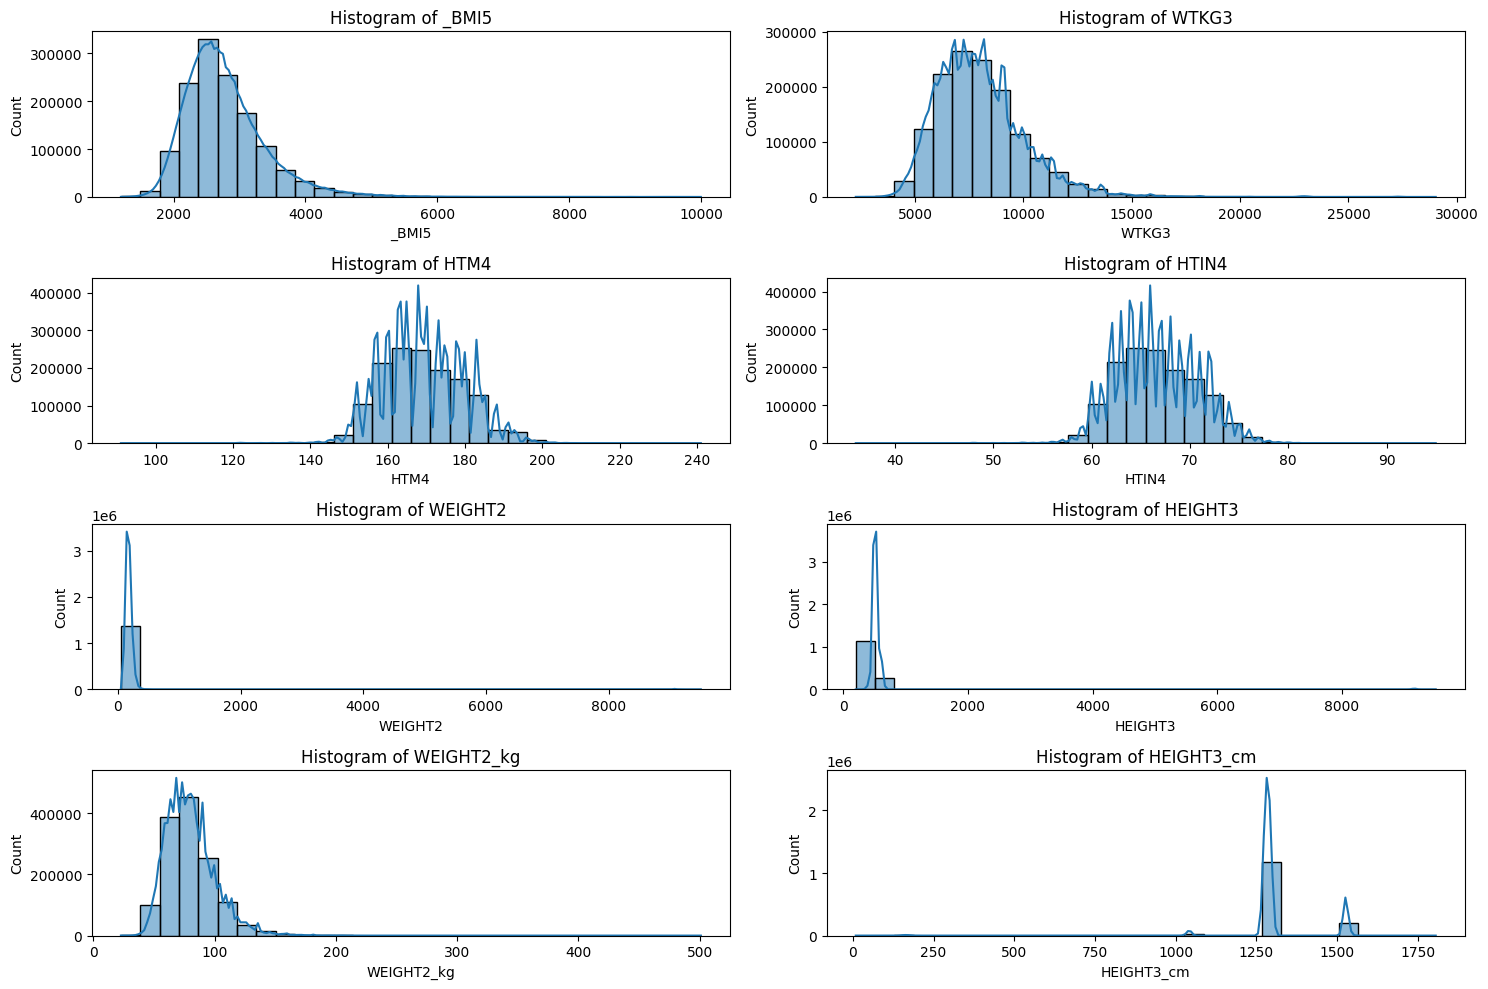

C:\Users\hasit\AppData\Local\Temp\ipykernel_12896\552137829.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='_BMI5CAT_LABEL', data=subset_df, palette='pastel', order=bmi_labels.values())


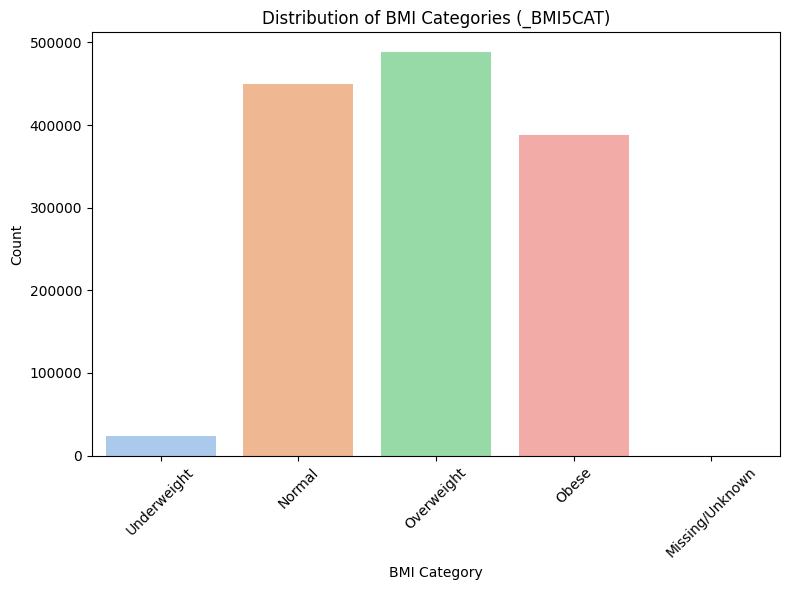

C:\Users\hasit\AppData\Local\Temp\ipykernel_12896\552137829.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='_RFBMI5_LABEL', data=subset_df, palette='pastel', order=rfbmi_labels.values())


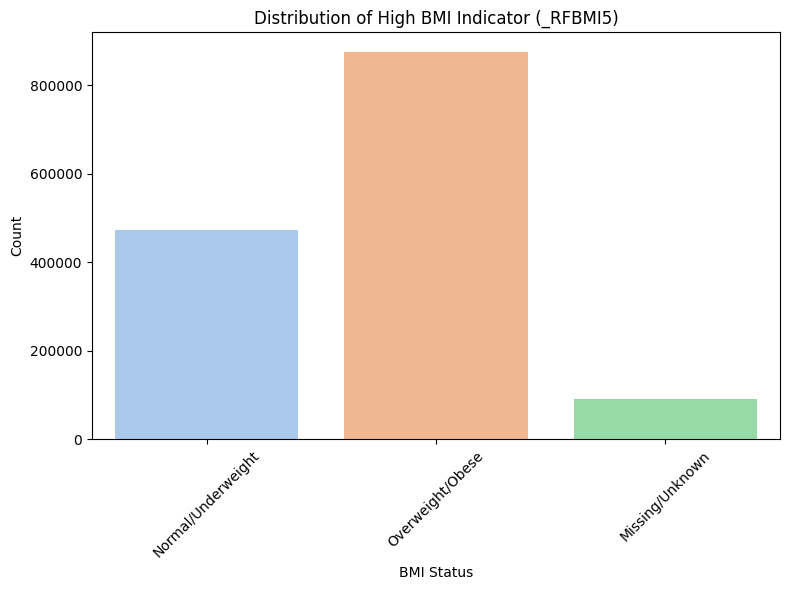

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/Behavioral_Risk_Factor_Surveillance_2011_2013_2015.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")

# Columns to analyze
columns_to_analyze = ['_BMI5', '_BMI5CAT', '_RFBMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4']

# Subset the dataset
subset_df = df[columns_to_analyze].copy()

# Define continuous and categorical columns
continuous_cols = ['_BMI5', 'WTKG3', 'HTM4', 'HTIN4', 'WEIGHT2', 'HEIGHT3']
categorical_cols = ['_BMI5CAT', '_RFBMI5']

# Step 1: Handle BRFSS special codes (7777, 9999 for "don't know"/"refused")
for col in continuous_cols:
    subset_df[col] = subset_df[col].replace([777, 7777, 999, 9999], np.nan)

# Step 2: Convert units for consistency
# Handle WEIGHT2 (pounds if <500, kg if 9000+)
subset_df['WEIGHT2_kg'] = subset_df['WEIGHT2'].apply(
    lambda x: x * 0.453592 if x < 500 else (x - 9000) if x >= 9000 else np.nan
)
# Handle HEIGHT3 (inches if <800, cm if 9000+)
subset_df['HEIGHT3_cm'] = subset_df['HEIGHT3'].apply(
    lambda x: x * 2.54 if x < 800 else (x - 9000) if x >= 9000 else np.nan
)

# Downcast numerical columns for memory efficiency
for col in continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm']:
    subset_df[col] = pd.to_numeric(subset_df[col], errors='coerce', downcast='float')

# Convert categoricals to category dtype
for col in categorical_cols:
    subset_df[col] = subset_df[col].astype('category')

# Step 3: Consistency check (e.g., WTKG3 vs WEIGHT2_kg, HTM4 vs HEIGHT3_cm)
print("\nConsistency Check:")
# WTKG3 (kg*100) vs WEIGHT2_kg (kg)
subset_df['WTKG3_check'] = (subset_df['WTKG3'] / 100) / subset_df['WEIGHT2_kg']
print(f"WTKG3/WEIGHT2_kg ratio (should be ~1):")
print(subset_df['WTKG3_check'].describe())
# HTM4 (m*100) vs HEIGHT3_cm (cm)
subset_df['HTM4_check'] = subset_df['HTM4'] / subset_df['HEIGHT3_cm']
print(f"HTM4/HEIGHT3_cm ratio (should be ~1):")
print(subset_df['HTM4_check'].describe())

# Step 4: Descriptive Statistics
print("\nDescriptive Statistics for Continuous Columns:")
print(subset_df[continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm']].describe())

# Step 5: Detect outliers (based on CDC/BRFSS and IQR)
print("\nOutlier Counts (based on CDC/BRFSS thresholds):")
outliers = {
    '_BMI5': ((subset_df['_BMI5'] / 100 < 15) | (subset_df['_BMI5'] / 100 > 50)).sum(),  # Adjusted for plausible range
    'WTKG3': ((subset_df['WTKG3'] / 100 < 22) | (subset_df['WTKG3'] / 100 > 200)).sum(),
    'HTM4': ((subset_df['HTM4'] / 100 < 0.91) | (subset_df['HTM4'] / 100 > 2.41)).sum(),
    'HTIN4': ((subset_df['HTIN4'] < 36) | (subset_df['HTIN4'] > 95)).sum(),
    'WEIGHT2_kg': ((subset_df['WEIGHT2_kg'] < 22) | (subset_df['WEIGHT2_kg'] > 200)).sum(),
    'HEIGHT3_cm': ((subset_df['HEIGHT3_cm'] < 91) | (subset_df['HEIGHT3_cm'] > 241)).sum()
}
for col, count in outliers.items():
    print(f"{col}: {count} outliers ({count/len(subset_df)*100:.2f}%)")

# Step 6: IQR-based outliers for comparison
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return len(data.loc[mask, column]), lower_bound, upper_bound

print("\nIQR Outlier Counts:")
for col in continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm']:
    if subset_df[col].notna().sum() > 0:
        iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
        print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Step 7: Value Counts for Categorical Columns
print("\nValue Counts and Percentages for Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    counts = subset_df[col].value_counts(dropna=False, sort=False)
    percentages = (counts / len(subset_df) * 100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percentage': percentages}))

# Step 8: Visualizations
# Boxplots for continuous columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm'], 1):
    if subset_df[col].notna().sum() > 0:
        plt.subplot(4, 2, i)
        sns.boxplot(x=subset_df[col])
        plt.title(f'Boxplot of {col}')
        plt.xlabel(col)
plt.tight_layout()
plt.show()

# Histograms for continuous columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols + ['WEIGHT2_kg', 'HEIGHT3_cm'], 1):
    if subset_df[col].notna().sum() > 0:
        plt.subplot(4, 2, i)
        sns.histplot(subset_df[col].dropna(), bins=30, kde=True)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
plt.tight_layout()
plt.show()

# Bar plots for categorical columns
bmi_labels = {1: 'Underweight', 2: 'Normal', 3: 'Overweight', 4: 'Obese', 9: 'Missing/Unknown'}
subset_df['_BMI5CAT_LABEL'] = subset_df['_BMI5CAT'].map(bmi_labels)
plt.figure(figsize=(8, 6))
sns.countplot(x='_BMI5CAT_LABEL', data=subset_df, palette='pastel', order=bmi_labels.values())
plt.title('Distribution of BMI Categories (_BMI5CAT)')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rfbmi_labels = {1: 'Normal/Underweight', 2: 'Overweight/Obese', 9: 'Missing/Unknown'}
subset_df['_RFBMI5_LABEL'] = subset_df['_RFBMI5'].map(rfbmi_labels)
plt.figure(figsize=(8, 6))
sns.countplot(x='_RFBMI5_LABEL', data=subset_df, palette='pastel', order=rfbmi_labels.values())
plt.title('Distribution of High BMI Indicator (_RFBMI5)')
plt.xlabel('BMI Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Summary Statistics for Rescaled Columns:
                BMI      height_m     weight_kg
count  1.439696e+06  1.439696e+06  1.439696e+06
mean   2.770059e+01  1.692259e+00  7.992264e+01
std    5.761962e+00  1.039063e-01  1.977293e+01
min    1.500000e+01  9.100000e-01  2.268000e+01
25%    2.383000e+01  1.630000e+00  6.577000e+01
50%    2.663000e+01  1.680000e+00  7.711000e+01
75%    3.041000e+01  1.780000e+00  9.072000e+01
max    5.000000e+01  2.410000e+00  2.000000e+02


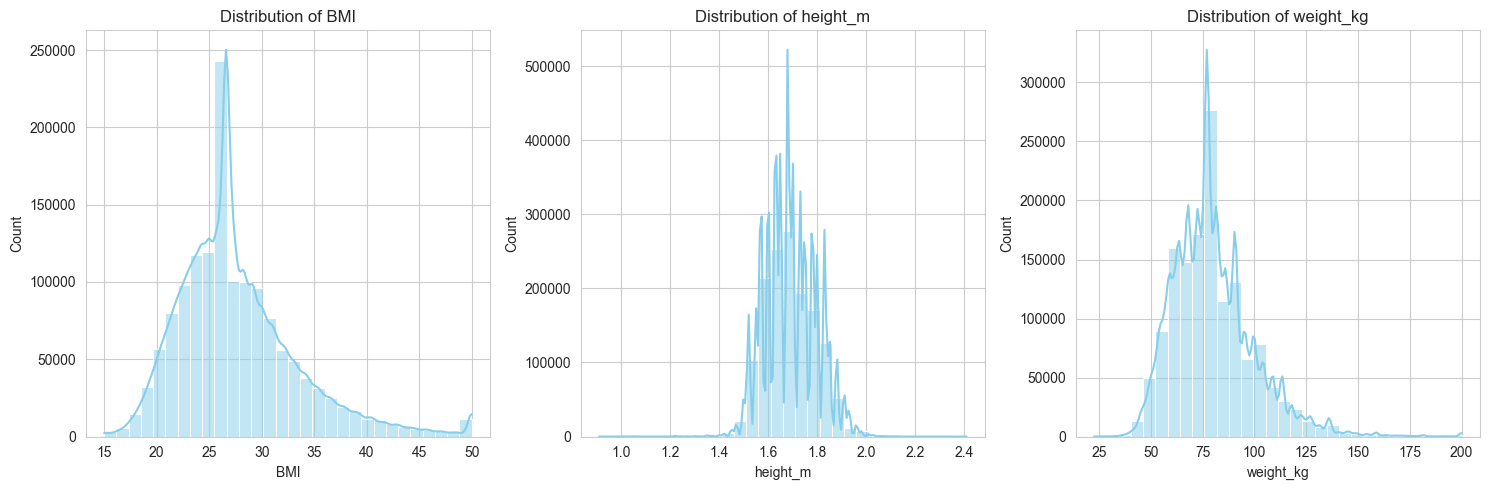

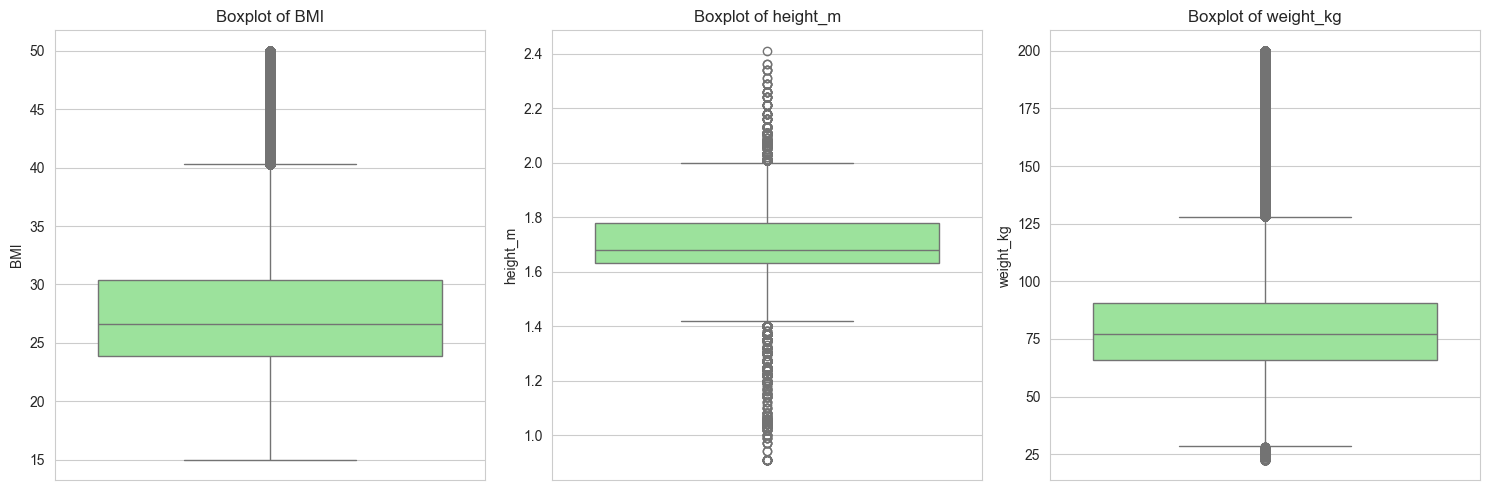

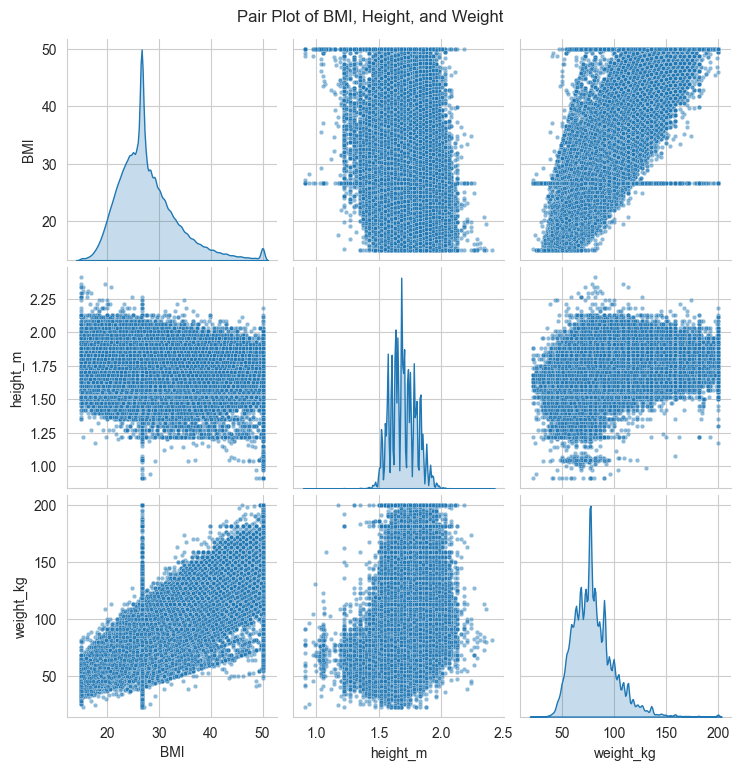

In [3]:
# Columns to rescale (based on BRFSS scaling: multiplied by 100)
bmi_col = '_BMI5'       # BMI * 100 (e.g., 3450 -> 34.5)
height_col = 'HTM4'     # Height in meters * 100 (e.g., 150 -> 1.5 m)
weight_col = 'WTKG3'    # Weight in kg * 100 (e.g., 8000 -> 80 kg)

# Handle any special codes or missing values (replace BRFSS codes like 9999 with NaN if not already done)
for col in [bmi_col, height_col, weight_col]:
    df[col] = df[col].replace([777, 7777, 999, 9999], np.nan)

# Create new rescaled columns
df['BMI'] = df[bmi_col] / 100.0  # Rescale to standard BMI (e.g., 34.5)
df['height_m'] = df[height_col] / 100.0  # Rescale to meters (e.g., 1.5)
df['weight_kg'] = df[weight_col] / 100.0  # Rescale to kg (e.g., 80.0)

# Handle outliers by capping based on plausible ranges (CDC-informed)
df['BMI'] = df['BMI'].clip(lower=15, upper=50)
df['height_m'] = df['height_m'].clip(lower=0.91, upper=2.41)
df['weight_kg'] = df['weight_kg'].clip(lower=22, upper=200)

# Impute missing values with median
for col in ['BMI', 'height_m', 'weight_kg']:
    df[col] = df[col].fillna(df[col].median())

# Verify changes with summary statistics
print("\nSummary Statistics for Rescaled Columns:")
print(df[['BMI', 'height_m', 'weight_kg']].describe())

# Visualizations
# Set up plot style
sns.set_style("whitegrid")

# 1. Histograms with KDE
plt.figure(figsize=(15, 5))
for i, col in enumerate(['BMI', 'height_m', 'weight_kg'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2. Boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(['BMI', 'height_m', 'weight_kg'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# 3. Pair Plot (relationships between features)
sns.pairplot(df[['BMI', 'height_m', 'weight_kg']], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Pair Plot of BMI, Height, and Weight', y=1.02)
plt.show()



BMI median used for imputation: 26.63
Shape after dropping ['_BMI5', '_BMI5CAT', '_RFBMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4', 'BMICal']: (1439696, 211)

Summary Statistics for Final BMI:
                BMI
count  1.439696e+06
mean   2.770059e+01
std    5.761962e+00
min    1.500000e+01
25%    2.383000e+01
50%    2.663000e+01
75%    3.041000e+01
max    5.000000e+01


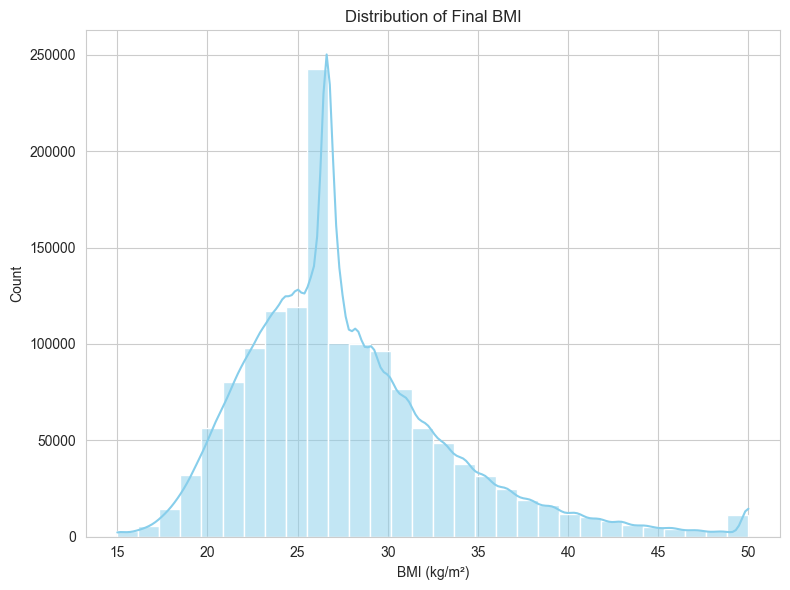

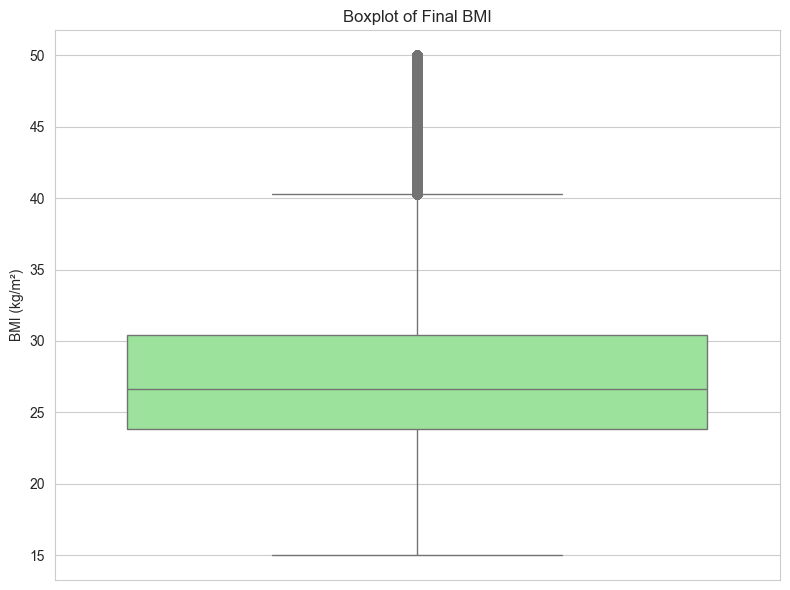


Updated dataset saved to: ../data/processed/BRFSS_1_BMI.csv


In [4]:
# Columns of interest
bmi_col = 'BMI'
height_col = 'height_m'
weight_col = 'weight_kg'
drop_cols = ['_BMI5', '_BMI5CAT', '_RFBMI5', 'WEIGHT2', 'WTKG3', 'HEIGHT3', 'HTM4', 'HTIN4']

# Step 1: Create BMICal from weight_kg and height_m
df['BMICal'] = df[weight_col] / (df[height_col] ** 2)

# Cap BMICal to plausible range (15-50, same as BMI)
df['BMICal'] = df['BMICal'].clip(lower=15, upper=50)

# Step 2: Fill missing BMI with BMICal where available, then median
df[bmi_col] = df.apply(
    lambda row: row['BMICal'] if pd.isna(row[bmi_col]) and not pd.isna(row['BMICal']) else row[bmi_col],
    axis=1
)
# Fill remaining missing BMI with median
bmi_median = df[bmi_col].median()
df[bmi_col] = df[bmi_col].fillna(bmi_median)
print(f"\nBMI median used for imputation: {bmi_median}")

# Step 3: Drop original and temporary columns
df = df.drop(columns=drop_cols + ['BMICal'])
print(f"Shape after dropping {drop_cols + ['BMICal']}: {df.shape}")

# Step 4: Summary statistics for final BMI
print("\nSummary Statistics for Final BMI:")
print(df[[bmi_col]].describe())

# Step 5: Visualizations for BMI
sns.set_style("whitegrid")

# Histogram with KDE
plt.figure(figsize=(8, 6))
sns.histplot(df[bmi_col], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Final BMI')
plt.xlabel('BMI (kg/m²)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df[bmi_col], color='lightgreen')
plt.title('Boxplot of Final BMI')
plt.ylabel('BMI (kg/m²)')
plt.tight_layout()
plt.show()

# Step 6: Save the updated dataset
updated_path = '../data/processed/BRFSS_1_BMI.csv'
df.to_csv(updated_path, index=False)
print(f"\nUpdated dataset saved to: {updated_path}")

## LifeStyle Features

Dataset shape: (1439696, 211)

Columns to analyze: ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', '_FRUTSUM', '_VEGESUM', 'FTJUDA1_', 'GRENDAY_', 'VEGEDA1_', 'FRUTDA1_', 'BEANDAY_', 'ORNGDAY_', '_FRUITEX', '_VEGETEX', '_MISFRTN', '_VEG23', '_FRT16', 'SMOKE100', 'SMOKDAY2', '_SMOKER3', '_RFSMOK3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', '_RFBING5', 'DROCDY3_', 'DRNKANY5']

Summary Statistics for Numerical Columns:
             FRUIT1       FRUITJU1       FVBEANS       FVGREEN       FVORANG  \
count  1.292328e+06  836026.000000  1.108130e+06  1.234762e+06  1.144069e+06   
mean   1.058614e+00       0.638173  3.332854e-01  5.972472e-01  3.427620e-01   
std    1.091038e+00       0.833411  4.631998e-01  6.460640e-01  4.320529e-01   
min    0.000000e+00       0.000000  0.000000e+00  0.000000e+00  0.000000e+00   
25%    4.285714e-01       0.142857  1.333333e-01  2.333333e-01  1.333333e-01   
50%    1.000000e+00       0.428571  2.000000e-01  4.285714e-01  2.333333e-0

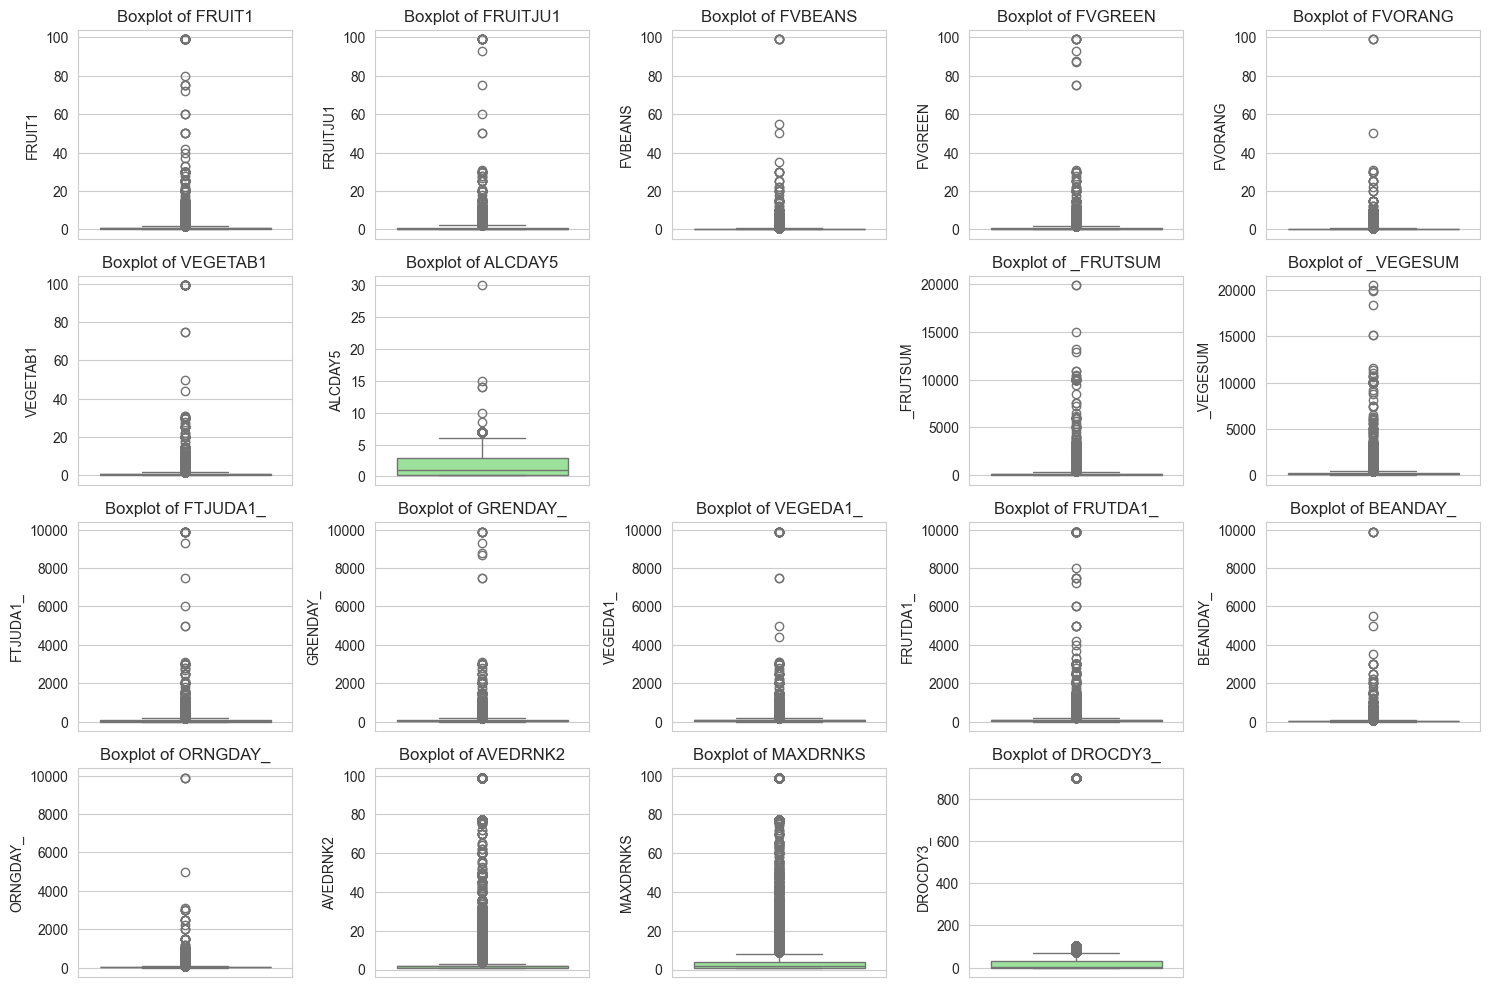

C:\Users\hasit\AppData\Local\Temp\ipykernel_12896\1630579936.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=subset_df[col], palette='pastel')
C:\Users\hasit\AppData\Local\Temp\ipykernel_12896\1630579936.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=subset_df[col], palette='pastel')
C:\Users\hasit\AppData\Local\Temp\ipykernel_12896\1630579936.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=subset_df[col], palette='pastel')
C:\Users\hasit\AppData\Local\Temp\ipykernel_12896\1630579936.py:101: FutureWarning: 

Pa

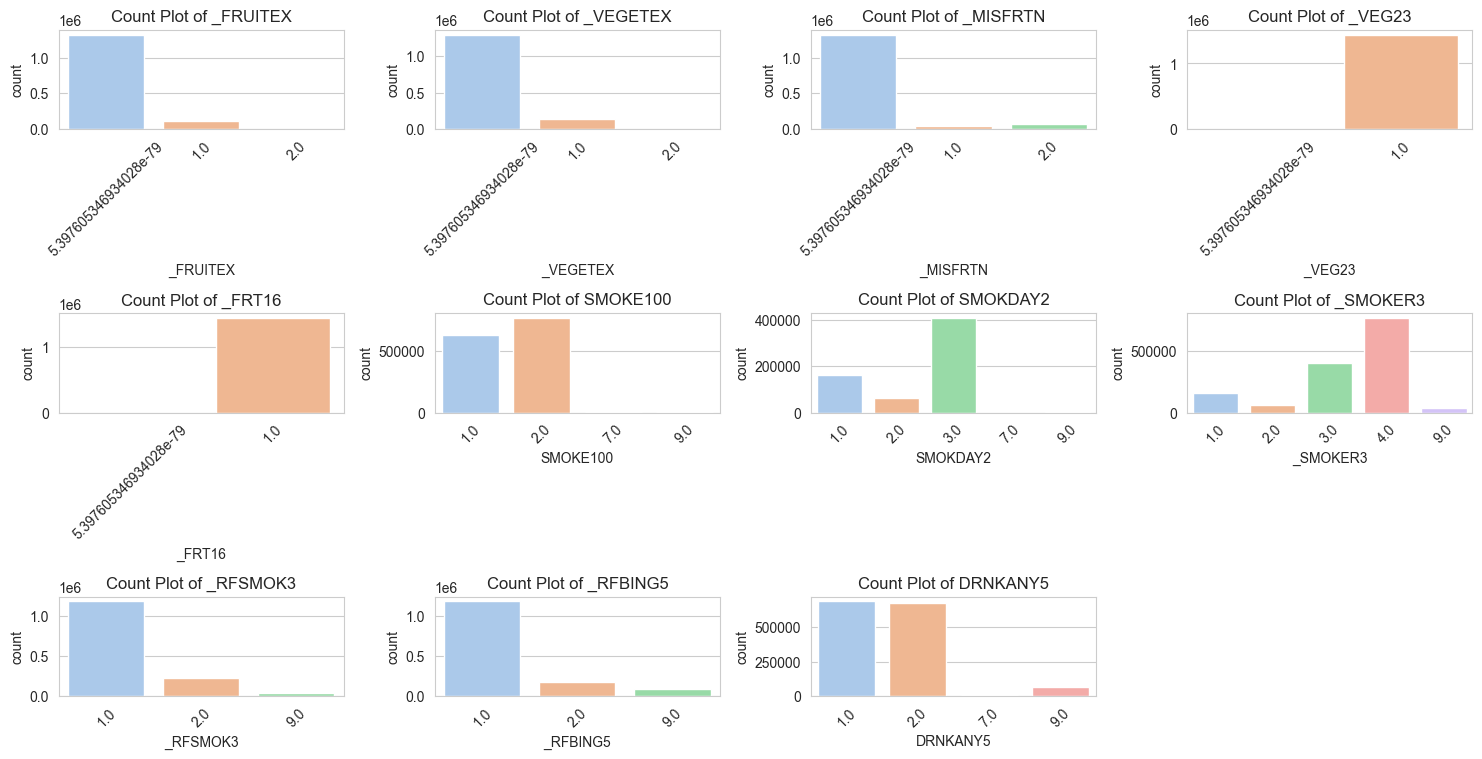

In [5]:
# Load the dataset
df = pd.read_csv('../data/processed/BRFSS_1_BMI.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")

# Define columns (remove duplicates)
diet_cols = ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1',
             '_FRUTSUM', '_VEGESUM', 'FTJUDA1_', 'GRENDAY_', 'VEGEDA1_',
             'FRUTDA1_', 'BEANDAY_', 'ORNGDAY_', '_FRUITEX', '_VEGETEX',
             '_MISFRTN', '_VEG23', '_FRT16']
smoking_cols = ['SMOKE100', 'SMOKDAY2', '_SMOKER3', '_RFSMOK3']
alcohol_cols = ['ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', '_RFBING5', 'DROCDY3_', 'DRNKANY5']

# Combine all columns
all_cols = diet_cols + smoking_cols + alcohol_cols
print(f"\nColumns to analyze: {all_cols}")

# Subset the dataset
subset_df = df[all_cols].copy()

# Define numerical and categorical columns
numerical_cols = ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1',
                  '_FRUTSUM', '_VEGESUM', 'FTJUDA1_', 'GRENDAY_', 'VEGEDA1_',
                  'FRUTDA1_', 'BEANDAY_', 'ORNGDAY_', 'ALCDAY5', 'AVEDRNK2',
                  'DRNK3GE5', 'MAXDRNKS', 'DROCDY3_']
categorical_cols = ['_FRUITEX', '_VEGETEX', '_MISFRTN', '_VEG23', '_FRT16',
                   'SMOKE100', 'SMOKDAY2', '_SMOKER3',
                   '_RFSMOK3', '_RFBING5', 'DRNKANY5']

# Step 1: Preprocess numerical columns
# Convert raw frequency columns to daily rates
freq_cols = ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', 'ALCDAY5', 'DRNK3GE5']
for col in freq_cols:
    subset_df[col] = subset_df[col].replace([777, 7777, 999, 9999, 888], np.nan)
    # Convert to daily: 100-199 (daily), 200-299 (weekly/7), 300-399 (monthly/30)
    subset_df[f'{col}'] = subset_df[col].apply(
        lambda x: x - 100 if 100 <= x <= 199 else (x - 200) / 7 if 200 <= x <= 299 else (x - 300) / 30 if 300 <= x <= 399 else np.nan
    )
numerical_cols = [f'{col}' for col in freq_cols] + [col for col in numerical_cols if col not in freq_cols]

# Handle special codes for other numerical columns
for col in numerical_cols:
    if col not in [f'{c}' for c in freq_cols]:
        subset_df[col] = subset_df[col].replace([777, 7777, 999, 9999, 888], np.nan)

# Convert to float for numerical columns
for col in numerical_cols:
    subset_df[col] = pd.to_numeric(subset_df[col], errors='coerce', downcast='float')

# Convert categorical columns to category dtype
for col in categorical_cols:
    subset_df[col] = subset_df[col].astype('category')

# Step 2: Numerical Analysis
# Summary statistics for numerical columns
print("\nSummary Statistics for Numerical Columns:")
print(subset_df[numerical_cols].describe())

# Outlier detection using IQR
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return len(data.loc[mask, column]), lower_bound, upper_bound

print("\nIQR Outlier Counts for Numerical Columns:")
for col in numerical_cols:
    if subset_df[col].notna().sum() > 0:
        iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
        print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Value counts for categorical columns
print("\nValue Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    counts = subset_df[col].value_counts(dropna=False)
    percentages = (counts / len(subset_df) * 100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percentage': percentages}))

# Step 3: Visualizations
sns.set_style("whitegrid")

# Boxplots for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    if subset_df[col].notna().sum() > 0:
        plt.subplot(4, 5, i)
        sns.boxplot(y=subset_df[col], color='lightgreen')
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
plt.tight_layout()
plt.show()

# Count plots for categorical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 4, i)
    sns.countplot(x=subset_df[col], palette='pastel')
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Original dataset shape: (1439696, 211)
Note: '_RFSEAT3', '_RFSEAT2' not found in dataset. Excluded from analysis.

Summary Statistics for Engineered Features:
         diet_score  smoking_status  alcohol_level
count  1.439696e+06    1.439696e+06   1.439696e+06
mean   9.831103e+00    7.050197e-01   2.507915e+00
std    9.277879e-01    9.820116e-01   2.410281e+00
min    1.079521e-78    0.000000e+00   5.397605e-79
25%    1.000000e+01    0.000000e+00   5.397605e-79
50%    1.000000e+01    0.000000e+00   3.000000e+00
75%    1.000000e+01    1.000000e+00   5.000000e+00
max    1.000000e+01    3.000000e+00   5.000000e+00

IQR Outlier Counts for Engineered Features:
diet_score: 53530 outliers (Lower: 10.00, Upper: 10.00)
smoking_status: 160767 outliers (Lower: -1.50, Upper: 2.50)
alcohol_level: 0 outliers (Lower: -7.50, Upper: 12.50)

Value Counts for smoking_status:
                 Count  Percentage
smoking_status                    
0.0             808393       56.15
1.0             408359     

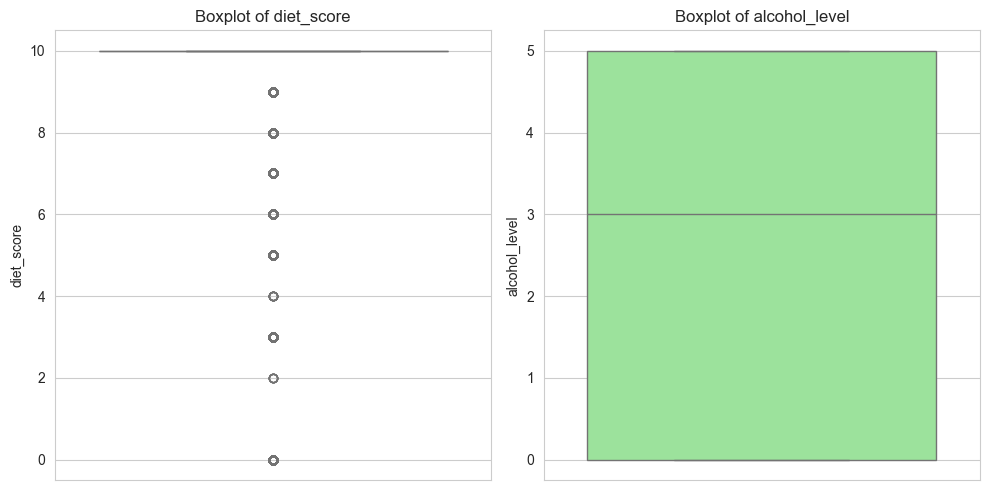

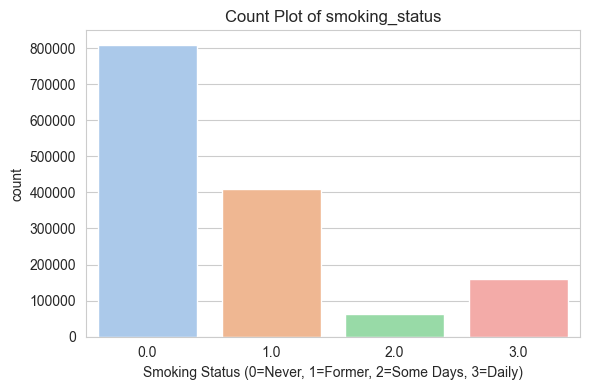


Updated dataset saved to: ../data/processed/BRFSS_2_Lifestyle.csv


<Figure size 800x600 with 0 Axes>

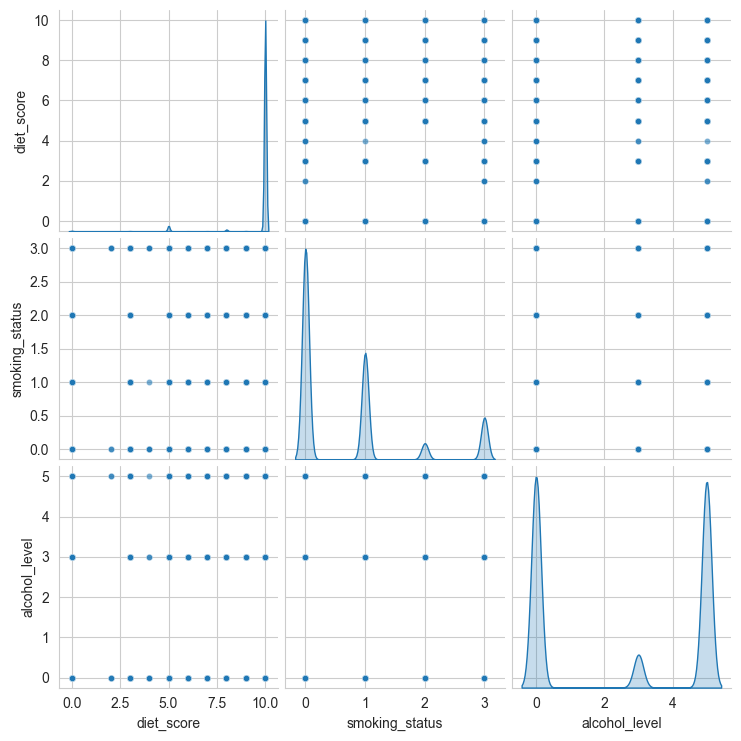

In [6]:
# Set pandas option to avoid downcasting warning
pd.set_option('future.no_silent_downcasting', True)

# Load the dataset
df = pd.read_csv('../data/processed/BRFSS_1_BMI.csv', low_memory=False)
print(f"Original dataset shape: {df.shape}")

# Define columns
diet_cols = ['FRUIT1', 'FRUITJU1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1',
             '_FRUTSUM', '_VEGESUM', 'FTJUDA1_', 'GRENDAY_', 'VEGEDA1_',
             'FRUTDA1_', 'BEANDAY_', 'ORNGDAY_', '_FRUITEX', '_VEGETEX',
             '_MISFRTN', '_VEG23', '_FRT16']
smoking_cols = ['SMOKE100', 'SMOKDAY2', '_SMOKER3', '_RFSMOK3']
alcohol_cols = ['ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', '_RFBING5', 'DROCDY3_', 'DRNKANY5']

# Remove duplicates and flag irrelevant columns
diet_cols = list(dict.fromkeys(diet_cols))
print(f"Note: '_RFSEAT3', '_RFSEAT2' not found in dataset. Excluded from analysis.")

# Combine all columns to drop
drop_cols = diet_cols + smoking_cols + alcohol_cols

# Define columns needed for engineering
eng_cols = ['_FRUTSUM', '_VEGESUM', '_SMOKER3', 'DROCDY3_']

# Subset the dataset
subset_df = df[eng_cols].copy()

# Step 1: Preprocess numerical columns
# Cap outliers at plausible ranges
caps = {
    '_FRUTSUM': 500,  # Max 5 times/day
    '_VEGESUM': 500,
    'DROCDY3_': 500   # Max 5 drinks/day
}
for col, cap in caps.items():
    subset_df[col] = subset_df[col].clip(upper=cap / 100)

# Replace special codes with NaN
for col in ['_FRUTSUM', '_VEGESUM', 'DROCDY3_']:
    subset_df[col] = subset_df[col].replace([777, 7777, 999, 9999, 888], np.nan)

# Impute missing values with median
for col in ['_FRUTSUM', '_VEGESUM', 'DROCDY3_']:
    subset_df[col] = subset_df[col].fillna(subset_df[col].median())

# Step 2: Preprocess categorical column
subset_df['_SMOKER3'] = subset_df['_SMOKER3'].astype('category')
mode = subset_df['_SMOKER3'].mode()[0] if not subset_df['_SMOKER3'].mode().empty else np.nan
subset_df['_SMOKER3'] = subset_df['_SMOKER3'].astype(object).fillna(mode).astype('category')

# Step 3: Engineer 3 features
# 1. Diet Score: Sum of _FRUTSUM and _VEGESUM (times/day)
subset_df['diet_score'] = (subset_df['_FRUTSUM'] + subset_df['_VEGESUM'])

# 2. Smoking Status: Map _SMOKER3 to ordinal (0=never, 1=former, 2=some days, 3=daily)
smoking_map = {4.0: 0, 3.0: 1, 2.0: 2, 1.0: 3, 9.0: 0}  # Imputed 9.0 as never
subset_df['smoking_status'] = subset_df['_SMOKER3'].map(smoking_map).astype(float)

# 3. Alcohol Level: Use DROCDY3_ (drinks/day)
subset_df['alcohol_level'] = subset_df['DROCDY3_']

# Step 4: Numerical Analysis
new_features = ['diet_score', 'smoking_status', 'alcohol_level']
print("\nSummary Statistics for Engineered Features:")
print(subset_df[new_features].describe())

# IQR Outlier Counts
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return len(data.loc[mask, column]), lower_bound, upper_bound

print("\nIQR Outlier Counts for Engineered Features:")
for col in new_features:
    iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
    print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Value Counts for smoking_status
print("\nValue Counts for smoking_status:")
counts = subset_df['smoking_status'].value_counts(dropna=False)
percentages = (counts / len(subset_df) * 100).round(2)
print(pd.DataFrame({'Count': counts, 'Percentage': percentages}))

# Step 5: Visualizations
sns.set_style("whitegrid")

# Boxplots for diet_score and alcohol_level
plt.figure(figsize=(10, 5))
for i, col in enumerate(['diet_score', 'alcohol_level'], 1):
    plt.subplot(1, 2, i)
    sns.boxplot(y=subset_df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Count plot for smoking_status
plt.figure(figsize=(6, 4))
sns.countplot(x=subset_df['smoking_status'], hue=subset_df['smoking_status'], palette='pastel', legend=False)
plt.title('Count Plot of smoking_status')
plt.xlabel('Smoking Status (0=Never, 1=Former, 2=Some Days, 3=Daily)')
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 6))

# Pairplot to visualize scatterplot matrix
sns.pairplot(
    subset_df[new_features],
    diag_kind='kde',             # KDE on the diagonal
    plot_kws={'alpha': 0.6, 's': 20}  # transparency & point size
)

# Step 6: Update the dataset
df = df.drop(columns=drop_cols + numerical_cols + categorical_cols)
df[new_features] = subset_df[new_features]
updated_path = '../data/processed/BRFSS_2_Lifestyle.csv'
df.to_csv(updated_path, index=False)
print(f"\nUpdated dataset saved to: {updated_path}")

## Health Conditions

Dataset shape: (1439696, 184)

Summary Statistics for Numerical Columns:
            MENTHLTH       PHYSHLTH       POORHLTH
count  418697.000000  488107.000000  298443.000000
mean       11.114500      12.102826      12.454251
std        10.658384      11.422077      11.144644
min         1.000000       1.000000       1.000000
25%         2.000000       2.000000       2.000000
50%         5.000000       5.000000      10.000000
75%        20.000000      25.000000      21.000000
max        30.000000      30.000000      30.000000

IQR Outlier Counts for Numerical Columns:
MENTHLTH: 0 outliers (Lower: -25.00, Upper: 47.00)
PHYSHLTH: 0 outliers (Lower: -32.50, Upper: 59.50)
POORHLTH: 0 outliers (Lower: -26.50, Upper: 49.50)

Value Counts for Categorical Columns:

_AGEG5YR:
           Count  Percentage
_AGEG5YR                    
NaN       297906       20.69
 8.0      153691       10.68
 10.0     147070       10.22
 13.0     119432        8.30
 11.0     117467        8.16
 6.0      107338   

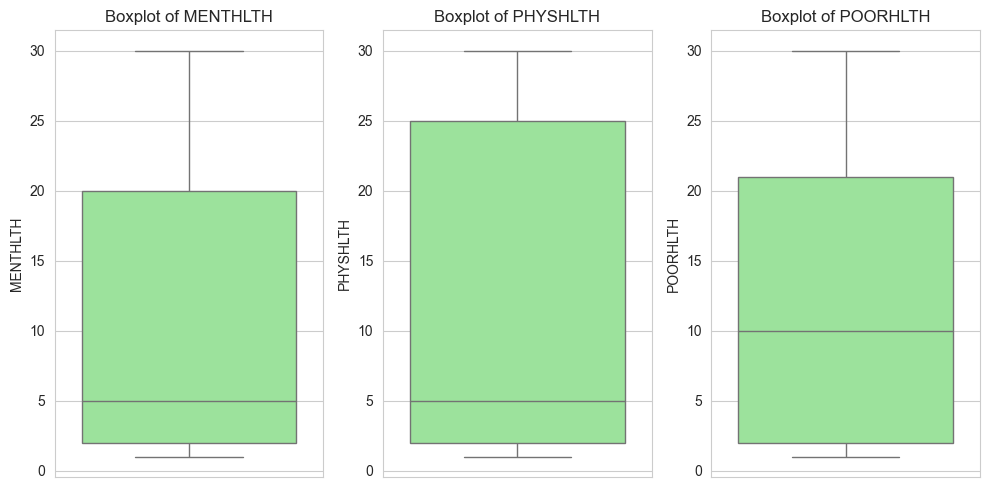

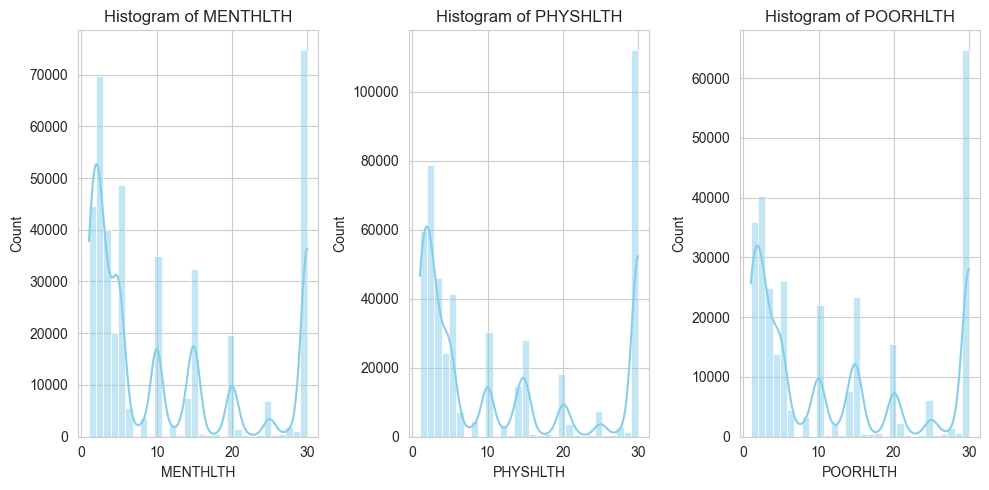

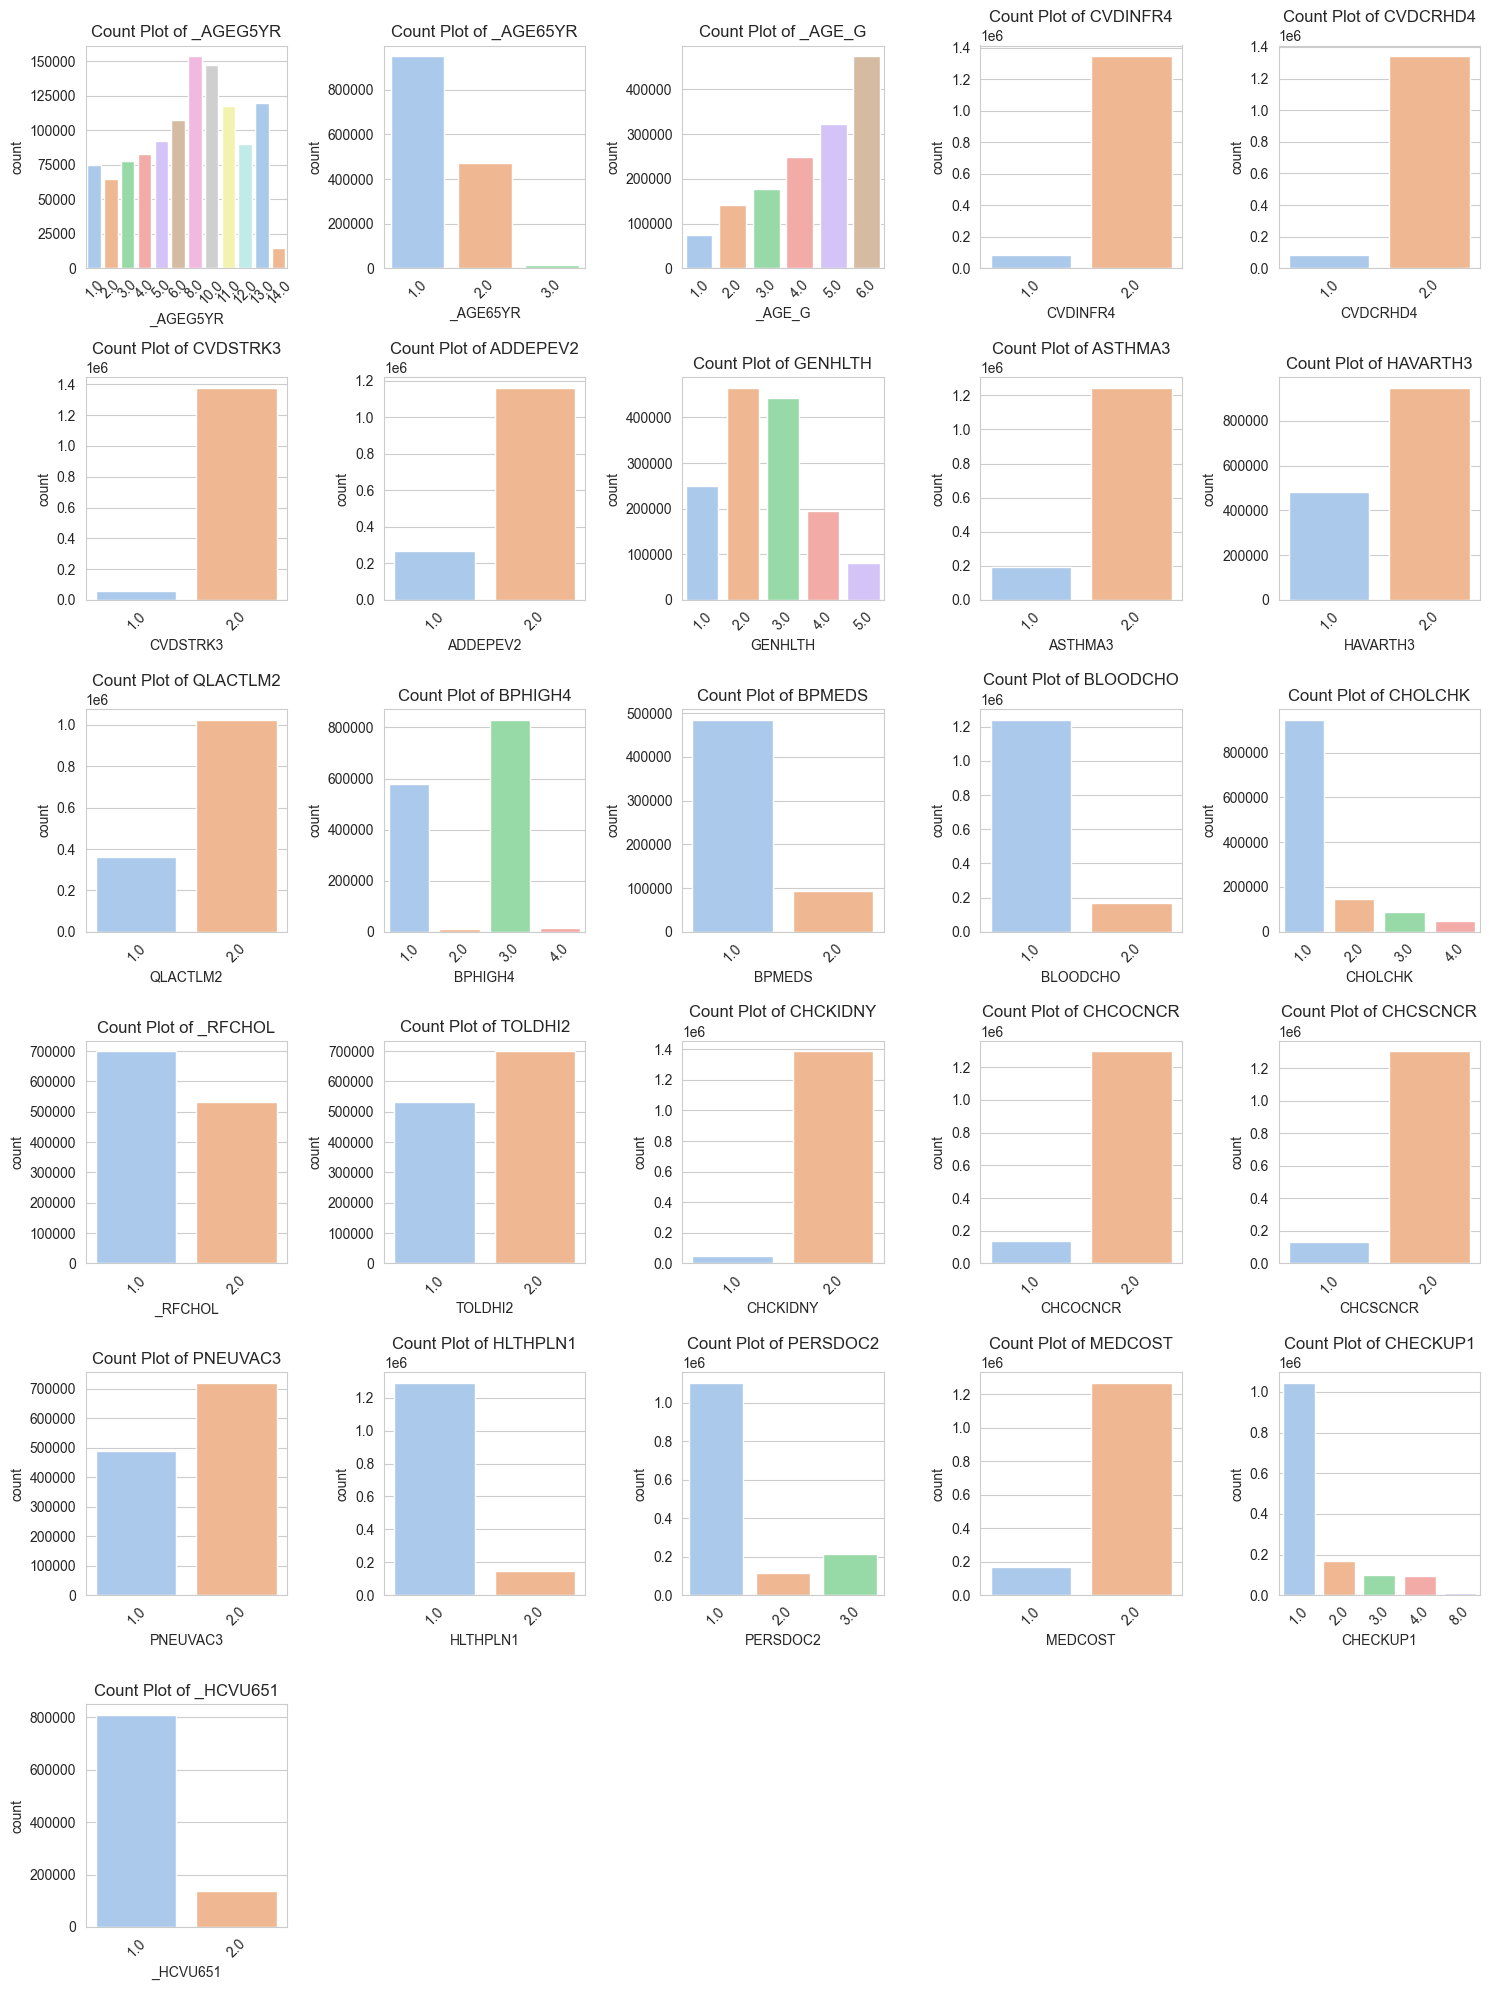

In [7]:
# Load the dataset
df = pd.read_csv('../data/processed/BRFSS_2_Lifestyle.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")

# Define column groups
age_cols = ['_AGEG5YR', '_AGE65YR', '_AGE_G']
cv_cols = ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3']
health_cols = ['MENTHLTH', 'PHYSHLTH', 'POORHLTH', 'ADDEPEV2', 'GENHLTH', 'ASTHMA3', 'HAVARTH3', 'QLACTLM2']
med_cols = ['BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', '_RFCHOL', 'TOLDHI2', 'CHCKIDNY', 'CHCOCNCR', 'CHCSCNCR', 'PNEUVAC3']
care_cols = ['HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', '_HCVU651']

# Combine all columns
all_cols = age_cols + cv_cols + health_cols + med_cols + care_cols

# Subset the dataset
subset_df = df[all_cols].copy()

# Step 1: Preprocess columns
# Replace BRFSS special codes with NaN (e.g., 7, 9, 77, 88, 99, 777, 999)
special_codes = [7, 9, 77, 88, 99, 777, 999]
for col in all_cols:
    subset_df[col] = subset_df[col].replace(special_codes, np.nan)

# Define numerical columns (days or continuous)
numerical_cols = ['MENTHLTH', 'PHYSHLTH', 'POORHLTH']

# Define categorical columns (rest are categorical or ordinal)
categorical_cols = [col for col in all_cols if col not in numerical_cols]

# Convert categorical columns to category dtype
for col in categorical_cols:
    subset_df[col] = subset_df[col].astype('category')

# Step 2: Numerical Analysis
# Summary statistics
print("\nSummary Statistics for Numerical Columns:")
print(subset_df[numerical_cols].describe())

# Outlier detection using IQR
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return len(data.loc[mask, column]), lower_bound, upper_bound

print("\nIQR Outlier Counts for Numerical Columns:")
for col in numerical_cols:
    iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
    print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Value Counts for Categorical Columns
print("\nValue Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    counts = subset_df[col].value_counts(dropna=False)
    percentages = (counts / len(subset_df) * 100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percentage': percentages}))

# Step 3: Visualizations
sns.set_style("whitegrid")

# Boxplots for numerical columns
plt.figure(figsize=(10, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=subset_df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Histogram for numerical columns
plt.figure(figsize=(10, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(subset_df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

# Count plots for categorical columns
plt.figure(figsize=(15, 20))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(6, 5, i)
    sns.countplot(x=subset_df[col], hue=subset_df[col], palette='pastel', legend=False)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Dataset shape: (1439696, 184)

Correlation Matrix for Original Health Columns:
          MENTHLTH  PHYSHLTH   GENHLTH
MENTHLTH  1.000000   0.33226  0.279993
PHYSHLTH  0.332260   1.00000  0.498670
GENHLTH   0.279993   0.49867  1.000000

Summary Statistics for Engineered Features:
          age_score  cv_risk_score  health_score  med_conditions_score  \
count  1.439696e+06   1.439696e+06  1.439696e+06          1.439696e+06   
mean   4.408323e+00   1.587273e-01  7.815476e-01          8.038141e-01   
std    1.536493e+00   4.821679e-01  1.907990e-01          8.314113e-01   
min    1.000000e+00   0.000000e+00  1.000000e-01          0.000000e+00   
25%    3.000000e+00   0.000000e+00  7.000000e-01          0.000000e+00   
50%    5.000000e+00   0.000000e+00  8.000000e-01          1.000000e+00   
75%    6.000000e+00   0.000000e+00  9.000000e-01          1.000000e+00   
max    6.000000e+00   3.000000e+00  1.000000e+00          3.000000e+00   

       care_access_score  
count       1.439696e+06  

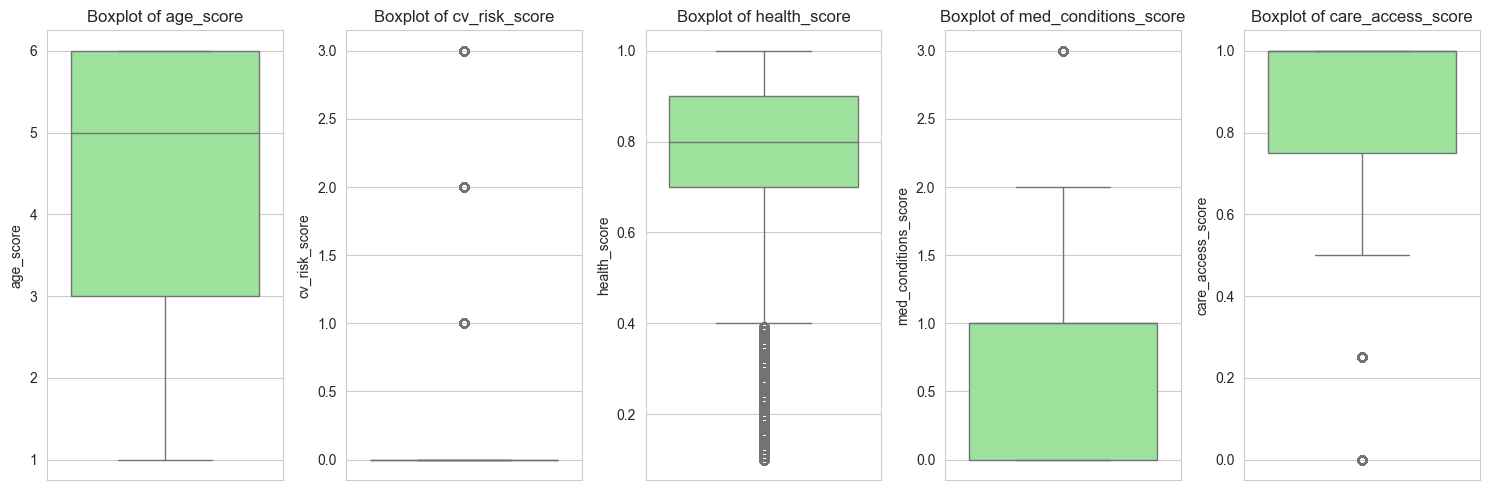

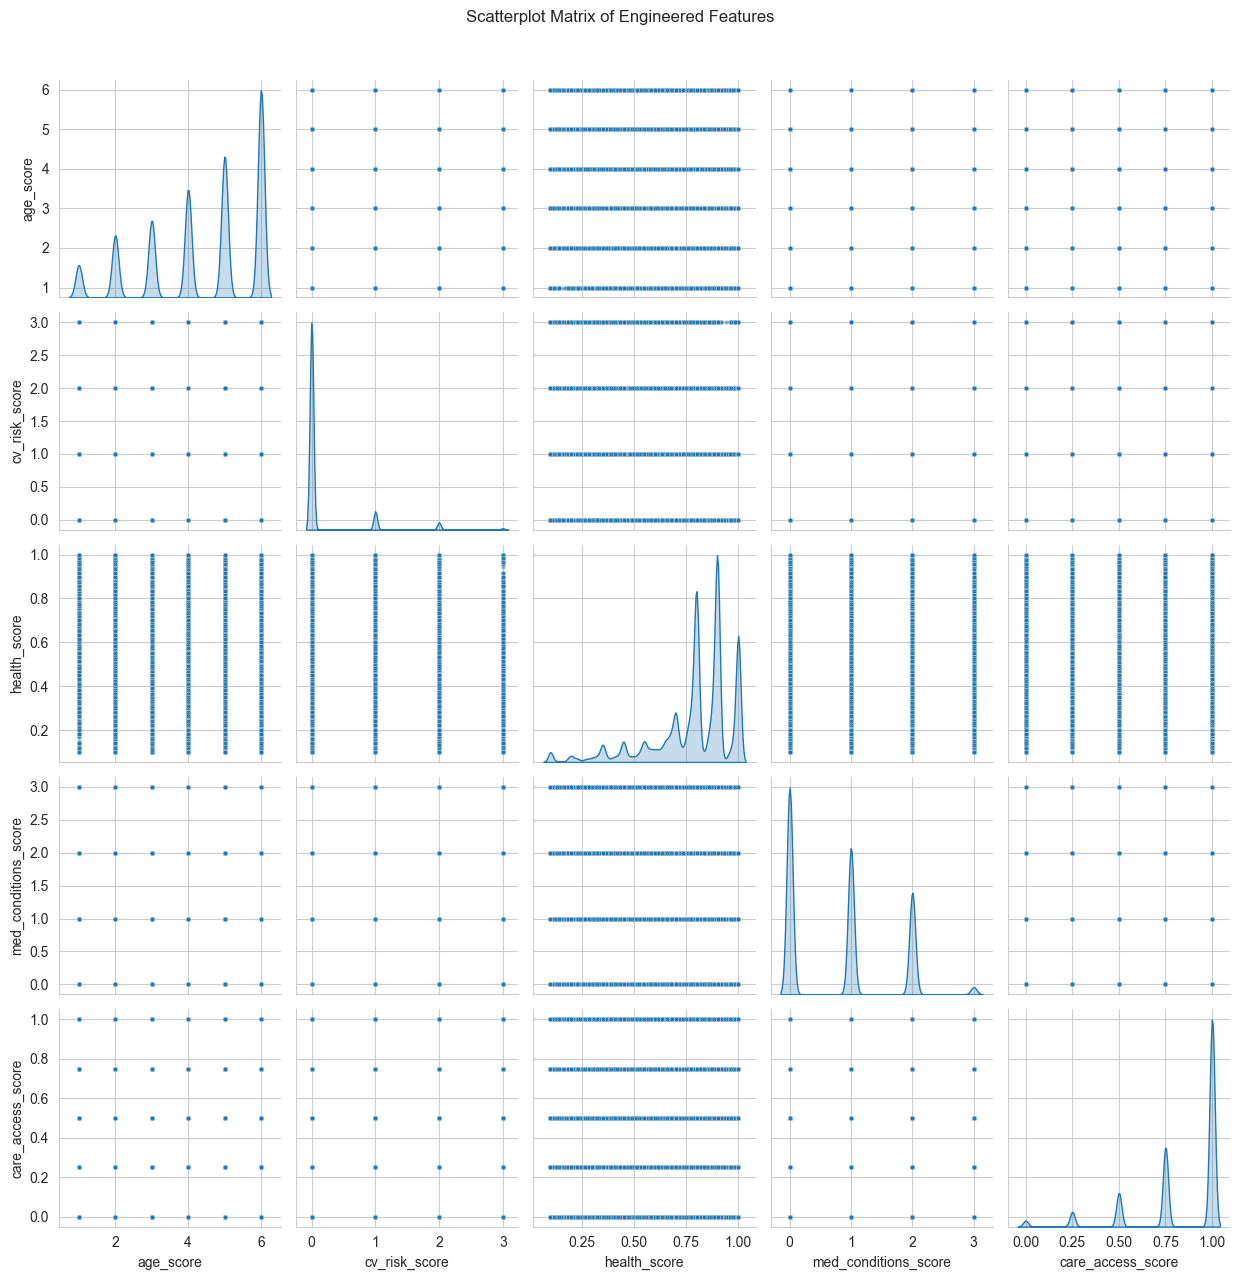


 Updated dataset saved to: ../data/processed/BRFSS_3_Health.csv


In [8]:
# Load the dataset
df = pd.read_csv('../data/processed/BRFSS_2_Lifestyle.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")

# Define column groups
age_cols = ['_AGEG5YR', '_AGE65YR', '_AGE_G']
cv_cols = ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3']
health_cols = ['MENTHLTH', 'PHYSHLTH', 'POORHLTH', 'ADDEPEV2', 'GENHLTH', 'ASTHMA3', 'HAVARTH3', 'QLACTLM2']
med_cols = ['BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', '_RFCHOL', 'TOLDHI2', 'CHCKIDNY', 'CHCOCNCR', 'CHCSCNCR', 'PNEUVAC3']
care_cols = ['HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', '_HCVU651']

# Combine all columns to be used or dropped
all_eng_cols = age_cols + cv_cols + health_cols + med_cols + care_cols

# Validate that required columns exist
required_for_eng = ['_AGE_G', 'MENTHLTH', 'PHYSHLTH', 'GENHLTH', 
                    'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1']
missing_cols = [col for col in required_for_eng if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Subset the dataset
subset_df = df[all_eng_cols].copy()

# Step 1: Preprocess — Replace BRFSS special codes with NaN
special_codes = [7, 9, 77, 88, 99, 777, 888, 999]
subset_df.replace(special_codes, np.nan, inplace=True)

# Define numerical vs categorical
numerical_cols = ['MENTHLTH', 'PHYSHLTH']
categorical_cols = [col for col in all_eng_cols if col not in numerical_cols]

# Impute numerical: 0 = no unhealthy days (standard BRFSS practice)
for col in numerical_cols:
    subset_df[col] = subset_df[col].fillna(0)

# Impute categorical: use mode (most frequent valid response)
for col in categorical_cols:
    mode_series = subset_df[col].mode()
    if not mode_series.empty:
        subset_df[col] = subset_df[col].fillna(mode_series[0])
    else:
        # Fallback: fill with 1.0 if no mode (rare)
        subset_df[col] = subset_df[col].fillna(1.0)

# Ensure float for mapping (avoid categorical dtype issues)
for col in categorical_cols:
    subset_df[col] = subset_df[col].astype(float)

# Step 2: Engineer 5 Features (CORRECTED)

# 1. Age Score: Use _AGE_G (1=18-24, 2=25-34, ..., 6=65+)
subset_df['age_score'] = subset_df['_AGE_G']

# 2. CV Risk Score: Count of confirmed CV conditions (1=yes, 2=no)
cv_map = {1.0: 1, 2.0: 0}
subset_df['cv_risk_score'] = subset_df[cv_cols].apply(
    lambda row: row.map(cv_map).fillna(0).sum(), axis=1
)

# 3. Health Score: Higher = HEALTHIER
# - Normalize unhealthy days (0-30 → 0-1), then reverse: 1 = perfect
# - Reverse GENHLTH: 1=excellent → 1.0, 5=poor → 0.0
ment_phys_avg = subset_df[['MENTHLTH', 'PHYSHLTH']].mean(axis=1)  # 0–30
unhealthy_norm = ment_phys_avg / 30.0  # 0–1 (higher = worse)
healthy_days_score = 1 - unhealthy_norm  # 0–1 (higher = better)

genhlth_reversed = (6 - subset_df['GENHLTH']) / 5.0  # maps 1→1.0, 5→0.2 → scale to 0–1

subset_df['health_score'] = (healthy_days_score + genhlth_reversed) / 2  # 0–1, higher = healthier

# 4. Medical Conditions Score: ONLY actual conditions (exclude PNEUVAC3!)
# Variables: 1=yes, 2=no (others already NaN → filled with mode, likely 2)
condition_cols = ['BPHIGH4', 'TOLDHI2', 'CHCKIDNY']  # Removed PNEUVAC3
med_map = {1.0: 1, 2.0: 0}
subset_df['med_conditions_score'] = subset_df[condition_cols].apply(
    lambda row: row.map(med_map).fillna(0).sum(), axis=1
)

# 5. Care Access Score: 4 equally weighted binary indicators (1 = good access)
# HLTHPLN1: 1=insured → 1
# PERSDOC2: 1/2=has doctor → 1
# CHECKUP1: 1=recent checkup → 1
# MEDCOST: 2=no cost barrier → 1
care_indicators = [
    (subset_df['HLTHPLN1'] == 1.0).astype(int),
    (subset_df['PERSDOC2'].isin([1.0, 2.0])).astype(int),
    (subset_df['CHECKUP1'] == 1.0).astype(int),
    (subset_df['MEDCOST'] == 2.0).astype(int)
]
subset_df['care_access_score'] = np.mean(care_indicators, axis=0)  # 0 to 1, higher = better access

# Step 3: Correlation Analysis (only on original health columns)
print("\nCorrelation Matrix for Original Health Columns:")
corr_cols = ['MENTHLTH', 'PHYSHLTH', 'GENHLTH']
print(subset_df[corr_cols].corr())

# Step 4: Summary & Outlier Analysis
new_features = ['age_score', 'cv_risk_score', 'health_score', 'med_conditions_score', 'care_access_score']
print("\nSummary Statistics for Engineered Features:")
print(subset_df[new_features].describe())

def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    if valid_data.empty:
        return 0, np.nan, np.nan
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return int(mask.sum()), lower_bound, upper_bound

print("\nIQR Outlier Counts for Engineered Features:")
for col in new_features:
    iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
    print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Step 5: Visualizations
sns.set_style("whitegrid")
plt.figure(figsize=(15, 5))
for i, col in enumerate(new_features, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(y=subset_df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

sns.pairplot(subset_df[new_features], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Scatterplot Matrix of Engineered Features', y=1.02)
plt.tight_layout()
plt.show()

# Step 6: Update the main dataset
df = df.drop(columns=all_eng_cols, errors='ignore')  # safely drop
df[new_features] = subset_df[new_features]

updated_path = '../data/processed/BRFSS_3_Health.csv'
df.to_csv(updated_path, index=False)
print(f"\n Updated dataset saved to: {updated_path}")

## Behavioral Factors

Loaded dataset with 1439696 rows and 160 columns.
Numerical columns (12): ['ASTHMAGE', 'ASACTLIM', 'ASDRVIST', 'ASERVIST', 'ASRCHKUP', 'HIVTSTD3', 'EXERHMM1', 'EXERHMM2', 'EXEROFT1', 'EXEROFT2', 'STRENGTH', 'STRFREQ_']
Categorical columns (33): ['ARTHDIS2', 'ARTHEDU', 'ARTHEXER', 'ARTHSOCL', 'ARTHWGT', 'ARTTODAY', 'ASTHMED3', 'ASTHNOW', 'ASYMPTOM', 'ASATTACK', 'ASINHALR', 'ASNOSLEP', 'ASPUNSAF', 'PROFEXAM', 'PSATEST1', 'PSATIME', 'HADMAM', 'HADPAP2', 'HADSGCO1', 'HADHYST2', 'LASTPAP2', 'LASTSIG3', 'LASTSMK2', 'LENGEXAM', 'HIVTST6', '_AIDTST3', 'EXERANY2', '_TOTINDA', '_PASTRNG', 'INCOME2', '_INCOMG', 'EDUCA', '_EDUCAG']

Summary Statistics for Numerical Columns:
          ASTHMAGE     ASACTLIM    ASDRVIST    ASERVIST     ASRCHKUP  \
count  3032.000000  1750.000000  433.000000  300.000000  1179.000000   
mean     62.324868   661.185714    9.981524    4.556667     8.811705   
std      32.781849   380.809320   25.029975   14.484917    23.021364   
min      11.000000     1.000000    1.0000

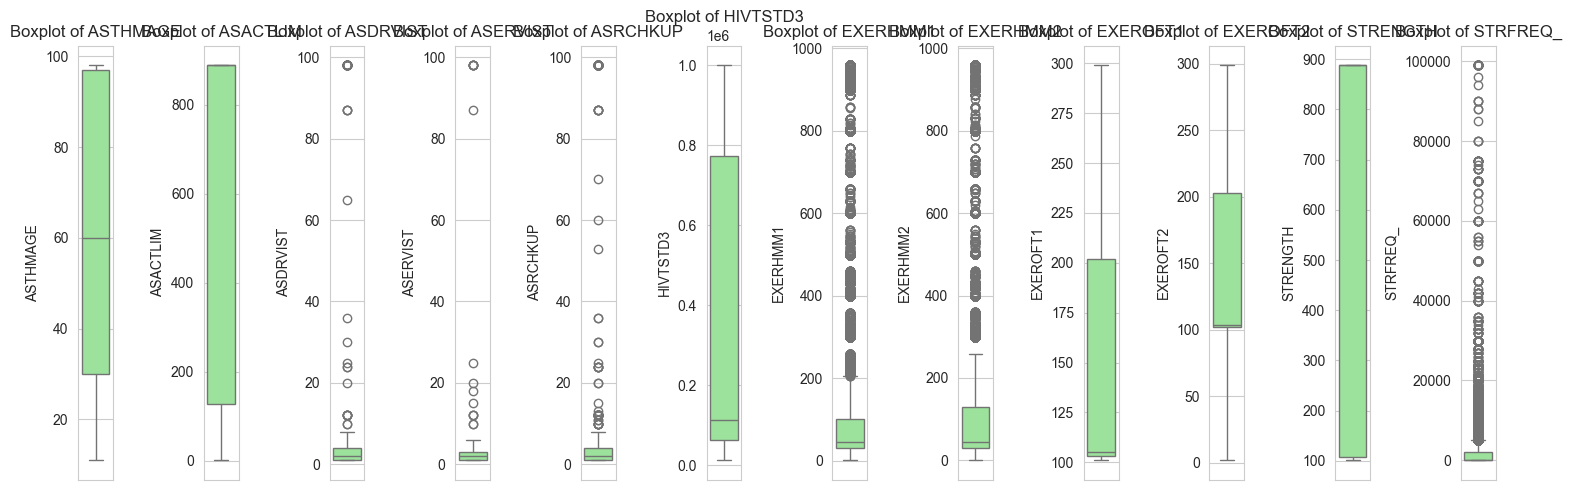

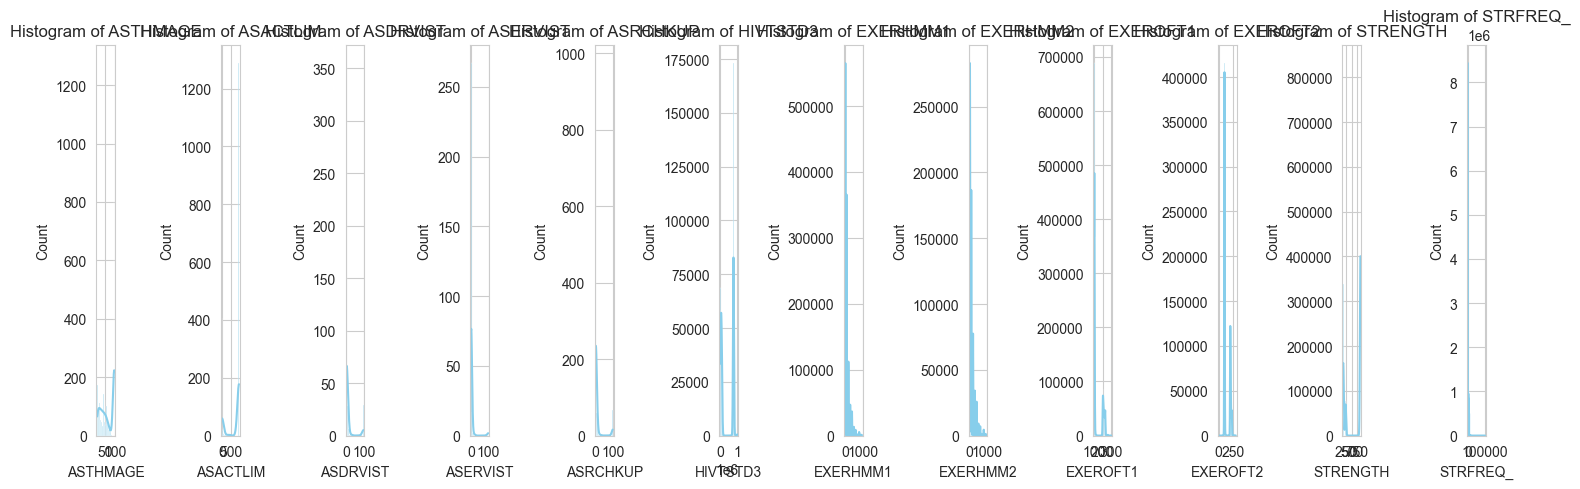

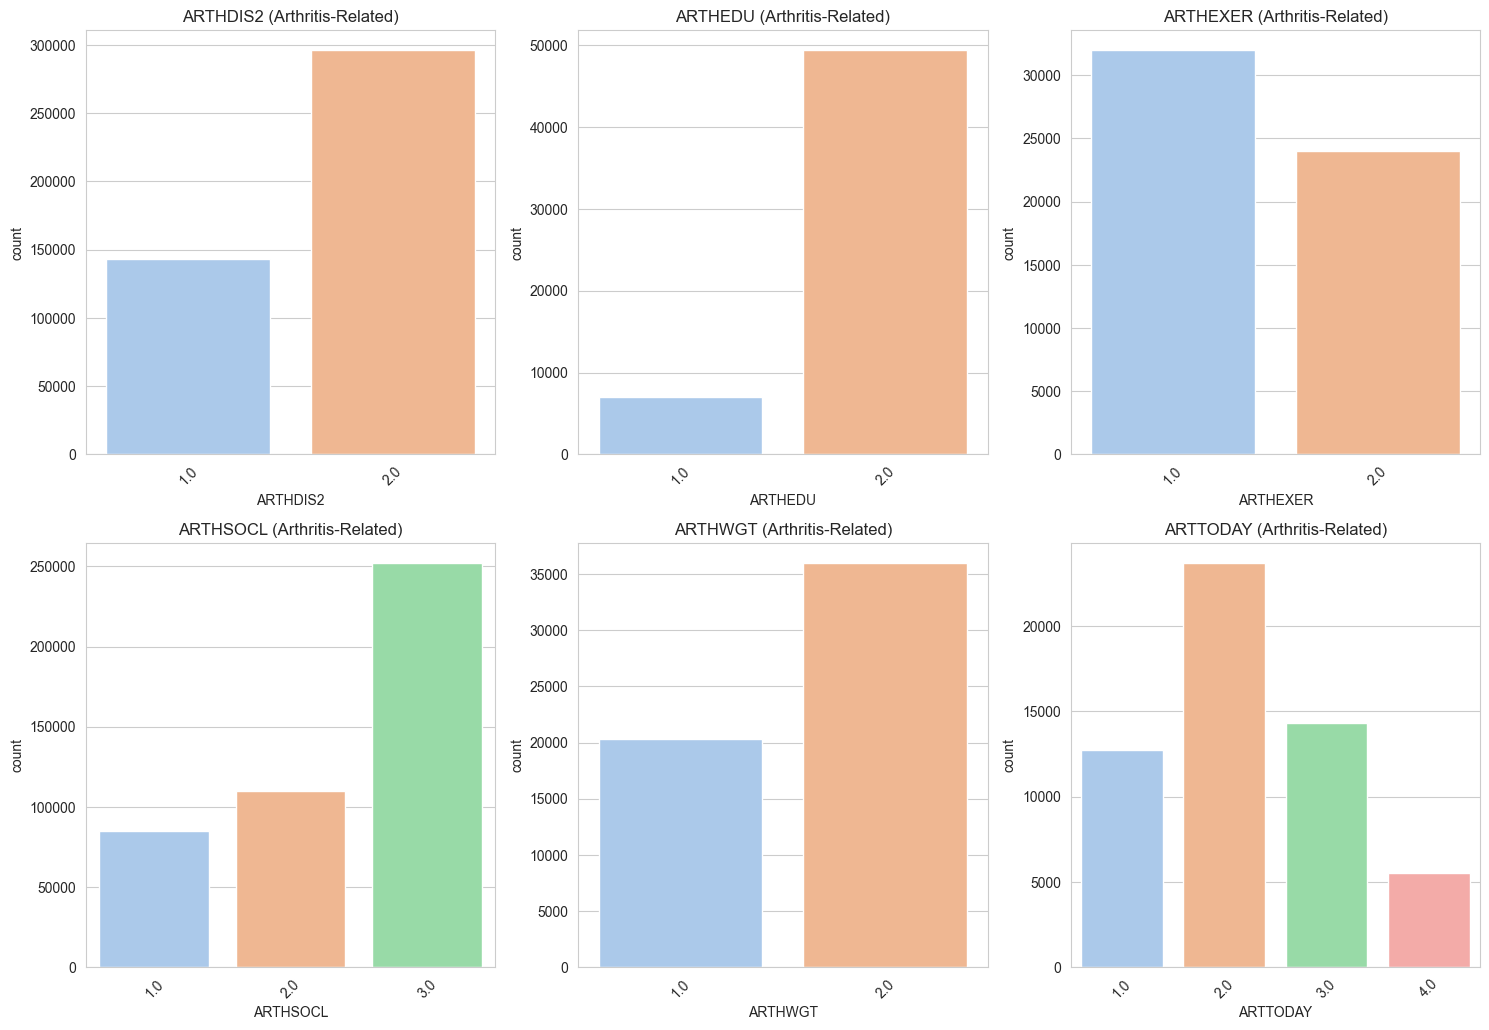

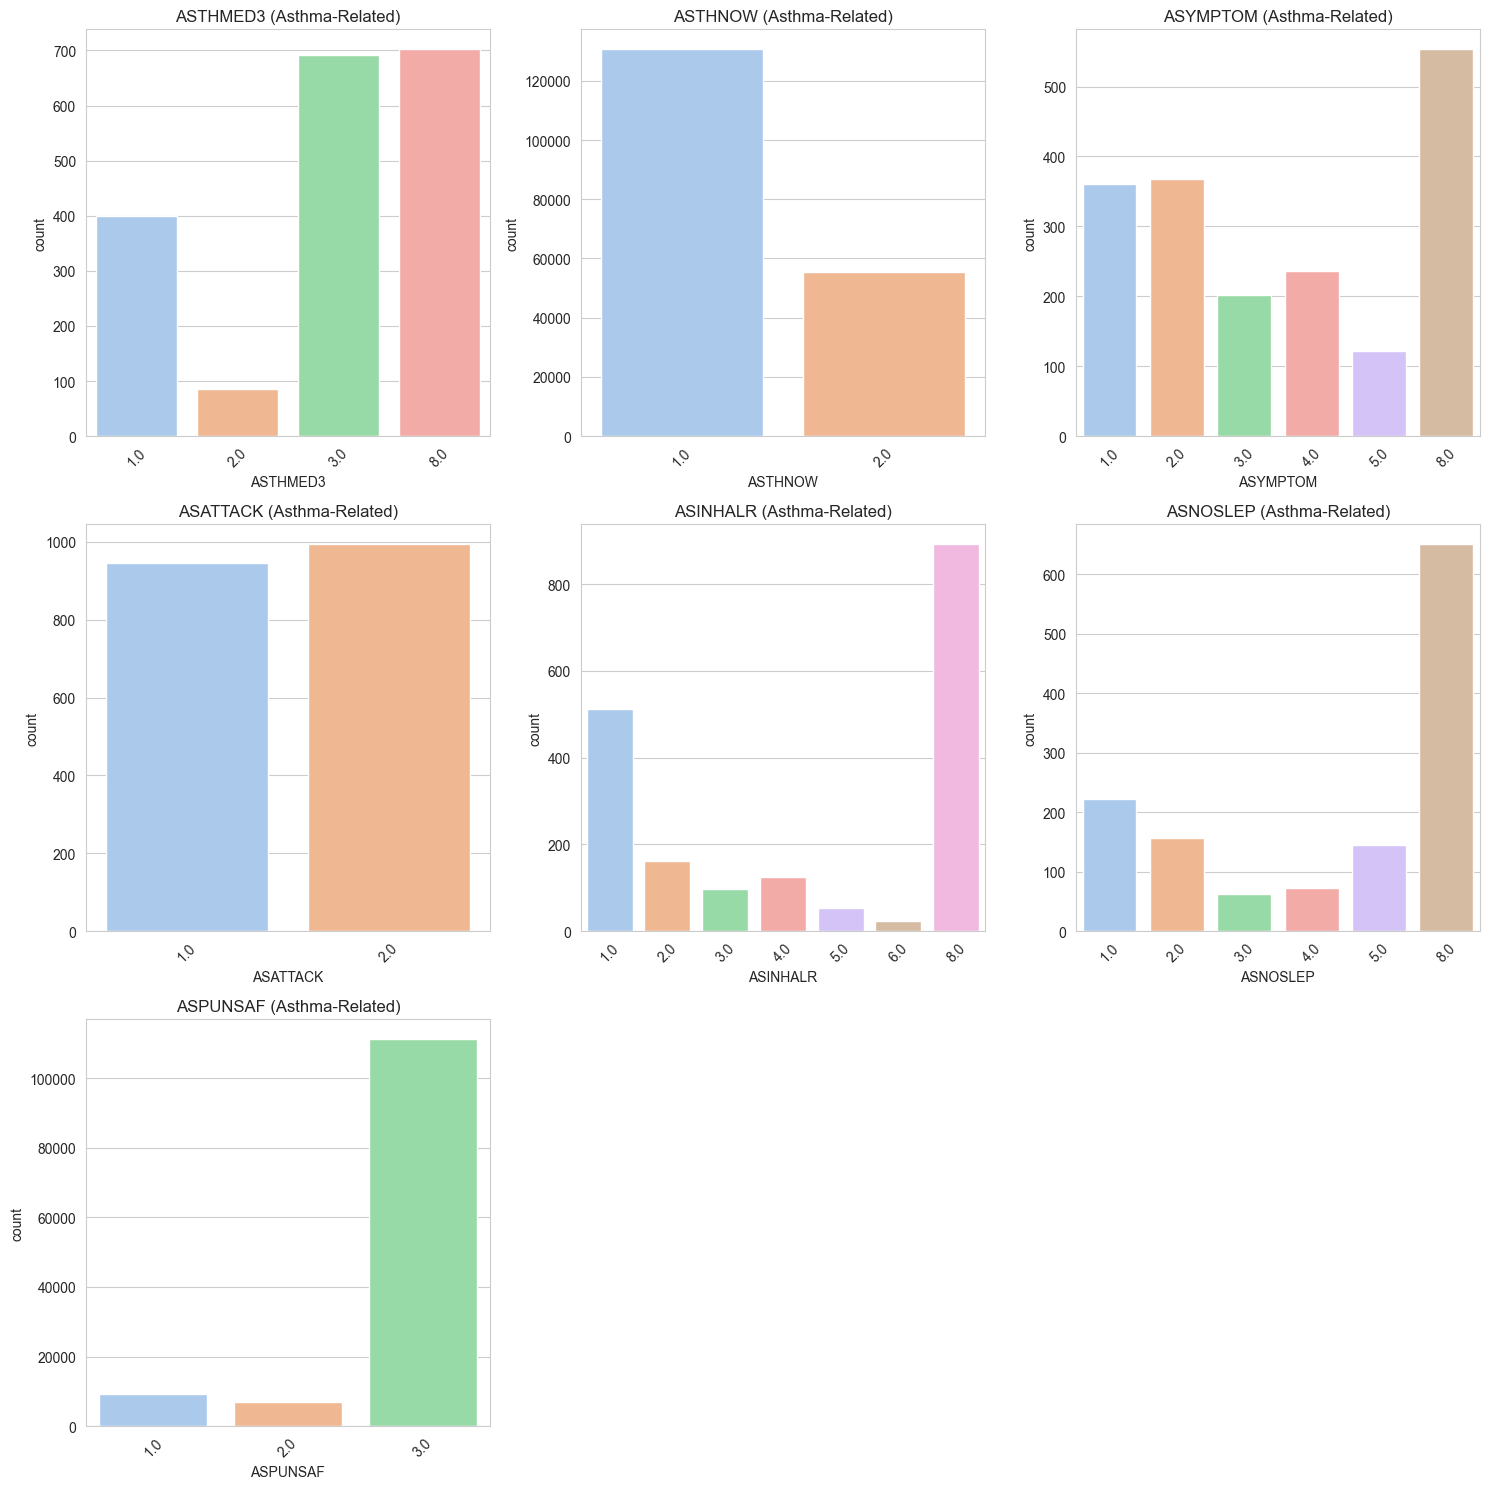

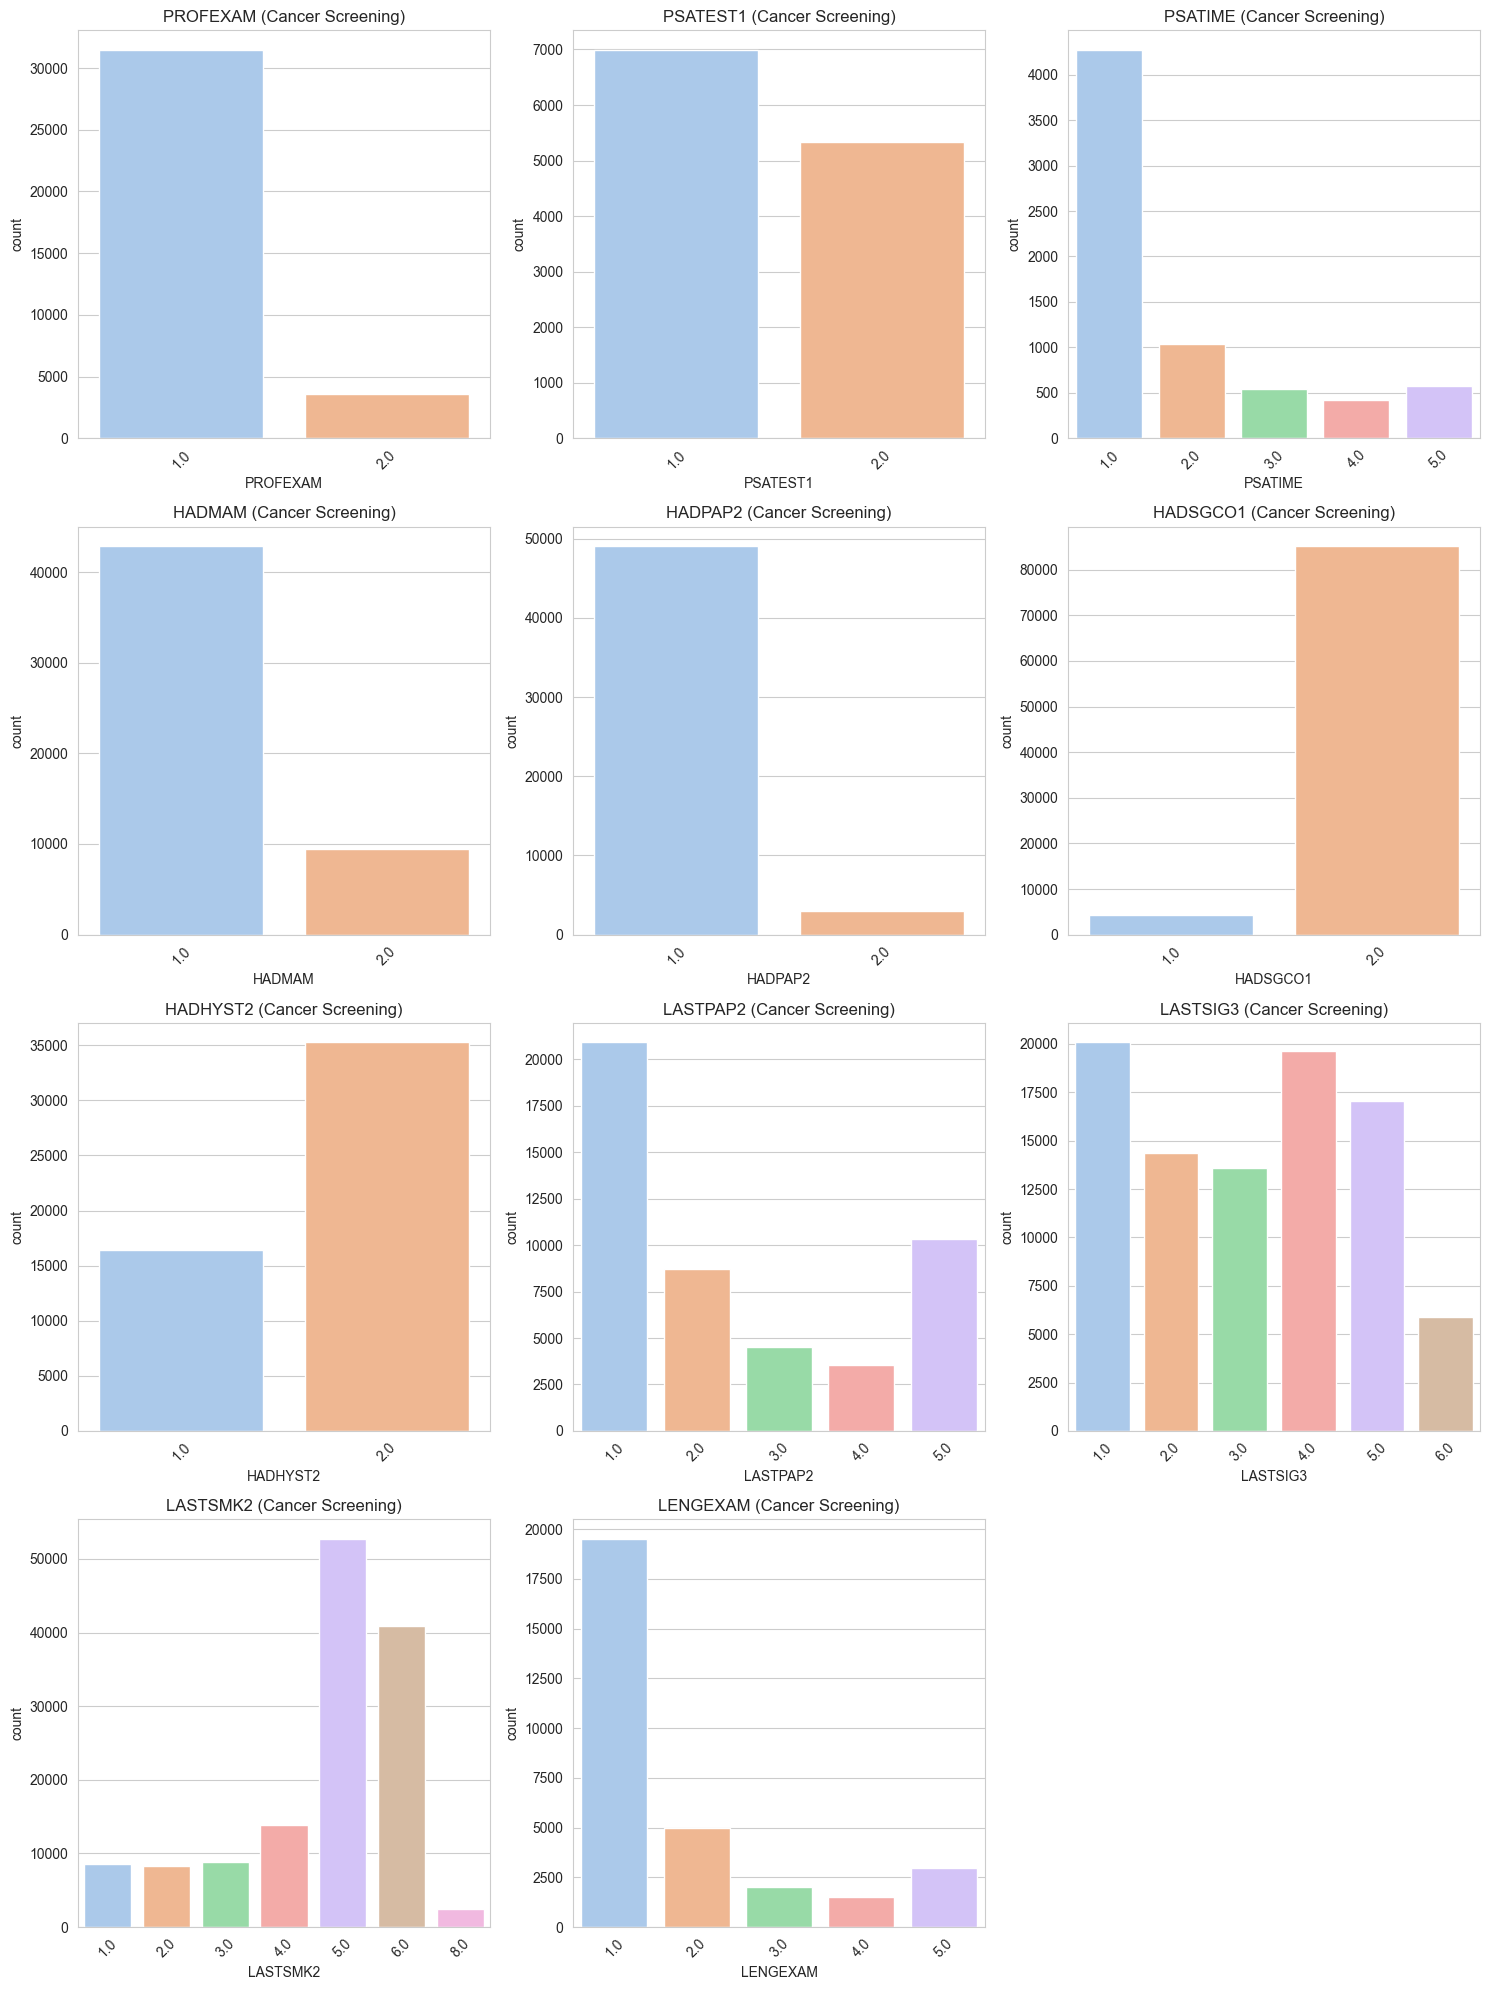

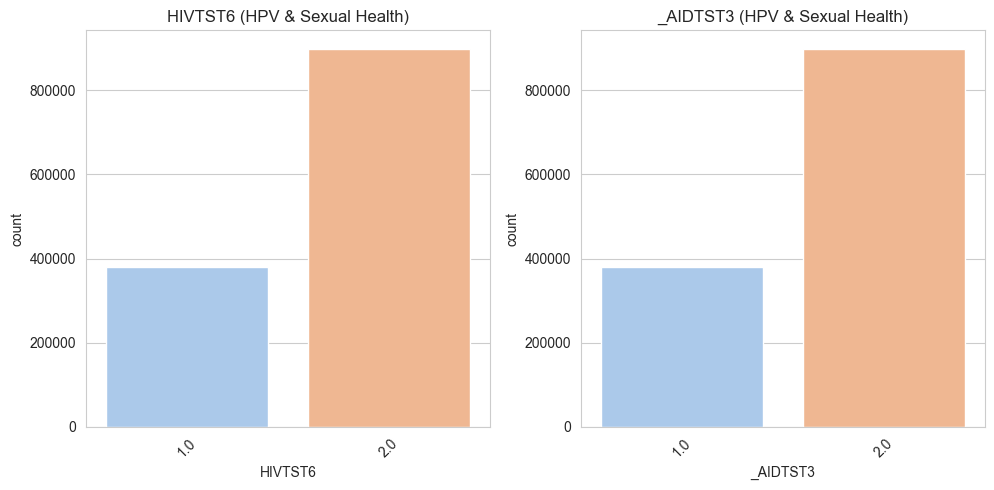

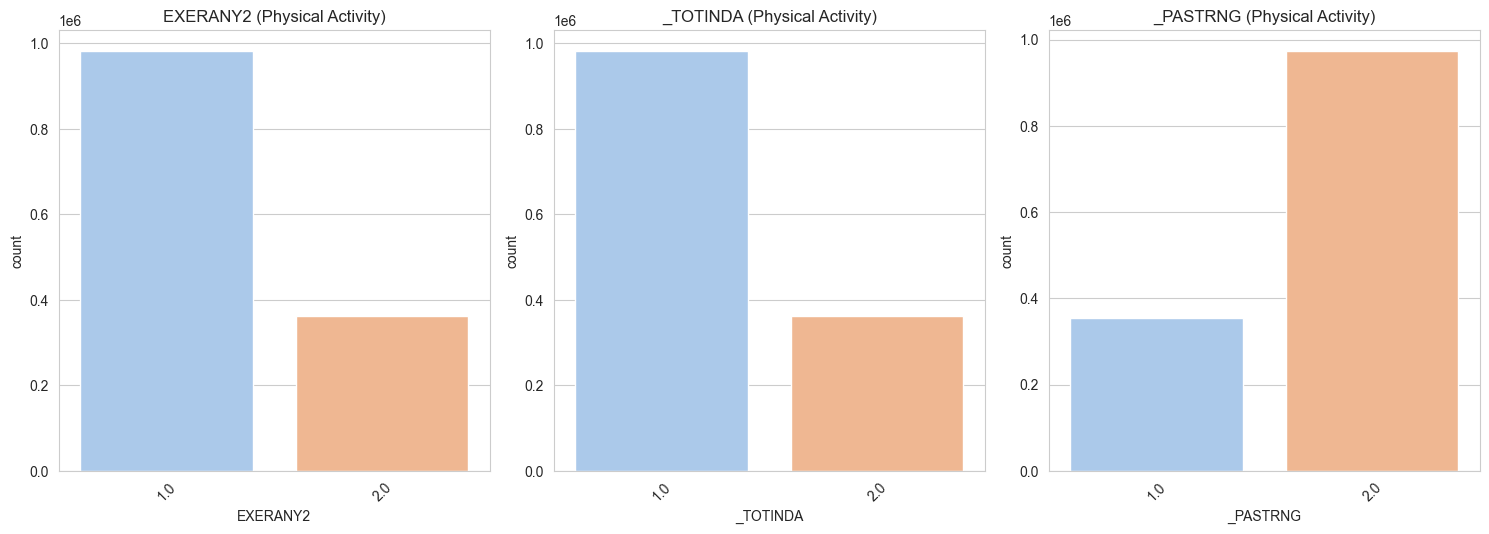

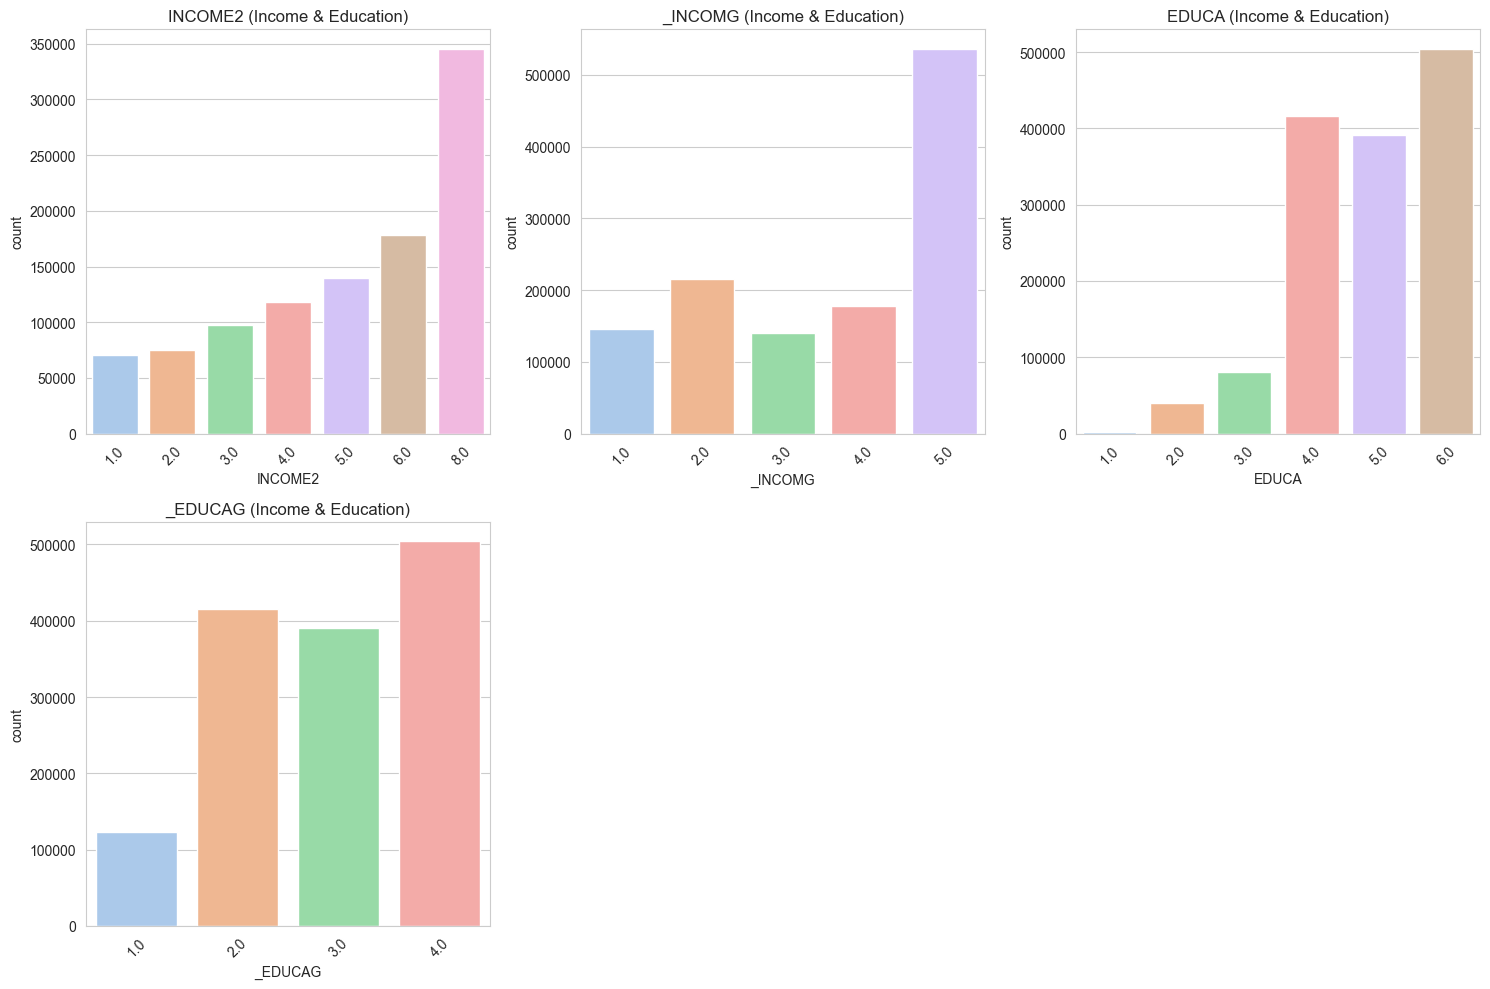

In [9]:
# Load dataset
df = pd.read_csv('../data/processed/BRFSS_3_Health.csv', low_memory=False)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

# Define column groups
arthritis_cols = ['ARTHDIS2', 'ARTHEDU', 'ARTHEXER', 'ARTHSOCL', 'ARTHWGT', 'ARTTODAY']
asthma_cols = ['ASTHMAGE', 'ASTHMED3', 'ASTHNOW', 'ASYMPTOM', 'ASACTLIM', 'ASATTACK',
               'ASDRVIST', 'ASERVIST', 'ASINHALR', 'ASNOSLEP', 'ASPUNSAF', 'ASRCHKUP']
cancer_screening_cols = ['PROFEXAM', 'PSATEST1', 'PSATIME', 'HADMAM', 'HADPAP2', 'HADSGCO1',
                         'HADHYST2', 'LASTPAP2', 'LASTSIG3', 'LASTSMK2', 'LENGEXAM']
hpv_sexual_health_cols = ['HIVTST6', 'HIVTSTD3', '_AIDTST3']
physical_activity_cols = ['EXERANY2', 'EXERHMM1', 'EXERHMM2', 'EXEROFT1', 'EXEROFT2',
                          '_TOTINDA', '_PASTRNG', 'STRENGTH', 'STRFREQ_']
income_education_cols = ['INCOME2', '_INCOMG', 'EDUCA', '_EDUCAG']

# Combine all columns
all_cols = (arthritis_cols + asthma_cols + cancer_screening_cols + hpv_sexual_health_cols + 
            physical_activity_cols + income_education_cols)

# Subset the dataset
subset_df = df[all_cols].copy()

# Step 1: Preprocess columns
# Replace BRFSS special codes with NaN (e.g., 7, 9, 77, 88, 99, 777, 999)
special_codes = [7, 9, 77, 88, 99, 777, 999]
for col in all_cols:
    subset_df[col] = subset_df[col].replace(special_codes, np.nan)

# Identify numerical columns (likely continuous or ordinal with >10 unique values)
numerical_cols = []
categorical_cols = []
for col in all_cols:
    unique_vals = subset_df[col].dropna().nunique()
    if unique_vals > 10:  # Threshold for numerical
        numerical_cols.append(col)
    else:
        categorical_cols.append(col)

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Convert categorical columns to category dtype
for col in categorical_cols:
    subset_df[col] = subset_df[col].astype('category')

# Step 2: Numerical Analysis
# Summary statistics for numerical columns
print("\nSummary Statistics for Numerical Columns:")
print(subset_df[numerical_cols].describe())

# Outlier detection using IQR for numerical columns
def detect_outliers_iqr(data, column):
    valid_data = data[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    return len(data.loc[mask, column]), lower_bound, upper_bound

print("\nIQR Outlier Counts for Numerical Columns:")
for col in numerical_cols:
    iqr_count, lower, upper = detect_outliers_iqr(subset_df, col)
    print(f"{col}: {iqr_count} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

# Value Counts for Categorical Columns (top 10 values + NaN)
print("\nValue Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    counts = subset_df[col].value_counts(dropna=False).head(10)
    percentages = (counts / len(subset_df) * 100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percentage': percentages}))

# Step 3: Visualizations
sns.set_style("whitegrid")

# Boxplots for numerical columns
if numerical_cols:
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(1, len(numerical_cols), i)
        sns.boxplot(y=subset_df[col], color='lightgreen')
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Histograms for numerical columns
if numerical_cols:
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(1, len(numerical_cols), i)
        sns.histplot(subset_df[col].dropna(), bins=30, kde=True, color='skyblue')
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Count plots for categorical columns (grouped by category to avoid overcrowding)
categories = {
    'Arthritis-Related': arthritis_cols,
    'Asthma-Related': asthma_cols,
    'Cancer Screening': cancer_screening_cols,
    'HPV & Sexual Health': hpv_sexual_health_cols,
    'Physical Activity': physical_activity_cols,
    'Income & Education': income_education_cols
}

for group_name, group_cols in categories.items():
    group_cat_cols = [col for col in group_cols if col in categorical_cols]
    if group_cat_cols:
        n_cols = len(group_cat_cols)
        plt.figure(figsize=(15, 5 * (n_cols // 3 + 1)))
        for i, col in enumerate(group_cat_cols, 1):
            plt.subplot((n_cols // 3 + 1), 3, i)
            sns.countplot(x=subset_df[col], hue=subset_df[col], palette='pastel', legend=False)
            plt.title(f'{col} ({group_name})')
            plt.xlabel(col)
            plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

Loaded dataset with 1439696 rows and 160 columns.
Shape after dropping original features: (1439696, 140)

 Summary of new binary features (mean = prevalence):
has_arthritis                0.100
arthritis_manages_weight     0.014
arthritis_exercises          0.022
current_asthma               0.091
asthma_attack_past_year      0.001
uses_inhaler                 0.000
current_smoker               0.018
never_smoked                 0.037
had_mammogram                0.030
had_pap_test                 0.034
had_colon_screening          0.003
ever_hiv_tested              0.263
meets_aerobic_guidelines     0.682
meets_strength_guidelines    0.344
any_physical_activity        0.682
low_ses_flag                 0.148
ARTHDIS2_missing             0.695
ASTHNOW_missing              0.871
HADMAM_missing               0.964
HADPAP2_missing              0.964
HADSGCO1_missing             0.938
dtype: float64


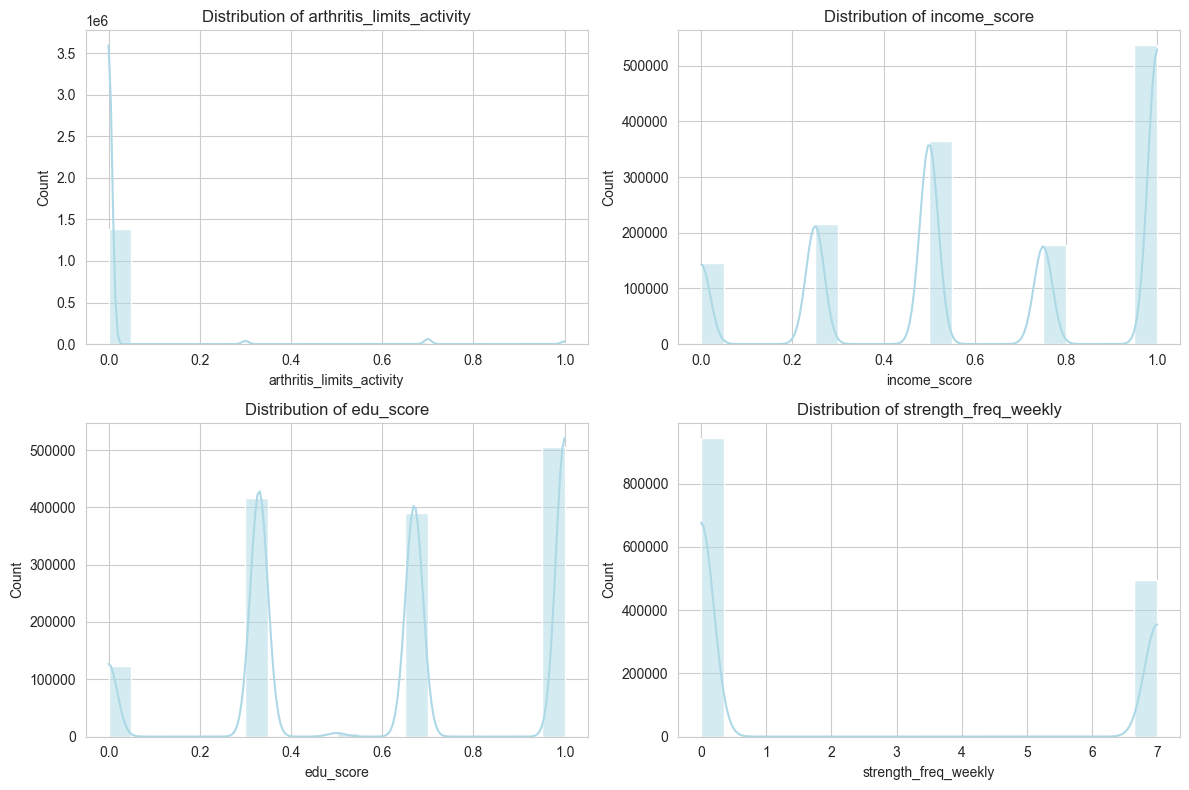


 Final dataset saved to: ../data/processed/BRFSS_4_Behavioral.csv
New features added: 24


In [10]:

# Load dataset
df = pd.read_csv('../data/processed/BRFSS_3_Health.csv', low_memory=False)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

# Define column groups
arthritis_cols = ['ARTHDIS2', 'ARTHEDU', 'ARTHEXER', 'ARTHSOCL', 'ARTHWGT', 'ARTTODAY']
asthma_cols = ['ASTHMAGE', 'ASTHMED3', 'ASTHNOW', 'ASYMPTOM', 'ASACTLIM', 'ASATTACK',
               'ASDRVIST', 'ASERVIST', 'ASINHALR', 'ASNOSLEP', 'ASPUNSAF', 'ASRCHKUP']
cancer_screening_cols = ['PROFEXAM', 'PSATEST1', 'PSATIME', 'HADMAM', 'HADPAP2', 'HADSGCO1',
                        'HADHYST2', 'LASTPAP2', 'LASTSIG3', 'LASTSMK2', 'LENGEXAM']
hpv_sexual_health_cols = ['HIVTST6', 'HIVTSTD3', '_AIDTST3']
physical_activity_cols = ['EXERANY2', 'EXERHMM1', 'EXERHMM2', 'EXEROFT1', 'EXEROFT2',
                         '_TOTINDA', '_PASTRNG', 'STRENGTH', 'STRFREQ_']
income_education_cols = ['INCOME2', '_INCOMG', 'EDUCA', '_EDUCAG']

all_eng_cols = (arthritis_cols + asthma_cols + cancer_screening_cols + 
                hpv_sexual_health_cols + physical_activity_cols + income_education_cols)

# Validate required columns exist
required_cols = ['ARTHDIS2', 'ASTHNOW', 'LASTSMK2', 'EXERANY2', '_TOTINDA', '_INCOMG', '_EDUCAG']
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Step 1: Handle BRFSS special codes
special_codes = [7, 9, 77, 88, 99, 777, 888, 999, 7777, 8888, 9999]
df.replace(special_codes, np.nan, inplace=True)

# Step 2: Helper functions for BRFSS recoding
def recode_frequency(val):
    """Recode BRFSS frequency variables (e.g., EXEROFT1: 101→1, 201→1, etc.)"""
    if pd.isna(val):
        return np.nan
    if 101 <= val <= 199:
        return val - 100
    elif 201 <= val <= 299:
        return val - 200
    elif val == 888 or val == 999:
        return np.nan
    else:
        return val

def recode_duration_minutes(val):
    """Recode duration in minutes (888 = missing, 999 = missing)"""
    if pd.isna(val) or val in [888, 999]:
        return np.nan
    return val

# Step 3: Create NEW FEATURES (corrected logic)

# ===== 1. Arthritis Features =====
df['has_arthritis'] = (df['ARTHDIS2'] == 1.0).astype(int)
df['arthritis_limits_activity'] = df['ARTTODAY'].map({1.0: 1, 2.0: 0.7, 3.0: 0.3, 4.0: 0}).fillna(0)
df['arthritis_manages_weight'] = (df['ARTHWGT'] == 1.0).astype(int)  # 1=yes, 2=no
df['arthritis_exercises'] = (df['ARTHEXER'] == 1.0).astype(int)

# ===== 2. Asthma Features =====
df['current_asthma'] = (df['ASTHNOW'] == 1.0).astype(int)
df['asthma_attack_past_year'] = (df['ASATTACK'] == 1.0).astype(int)
df['uses_inhaler'] = (df['ASINHALR'] == 1.0).astype(int)

# ===== 3. Cancer & Smoking Features =====
# LASTSMK2: 1=within days, 2=within weeks, 3=within year, 4=1+ years ago, 5=never, 6=unknown
df['current_smoker'] = df['LASTSMK2'].isin([1.0, 2.0, 3.0]).astype(int)
df['never_smoked'] = (df['LASTSMK2'] == 5.0).astype(int)

# Screening (1 = up-to-date/recent)
df['had_mammogram'] = (df['HADMAM'] == 1.0).astype(int)
df['had_pap_test'] = (df['HADPAP2'] == 1.0).astype(int)
df['had_colon_screening'] = (df['HADSGCO1'] == 1.0).astype(int)

# ===== 4. HIV/Sexual Health =====
df['ever_hiv_tested'] = (df['HIVTST6'] == 1.0).astype(int)

# ===== 5. Physical Activity Features =====
# Use BRFSS's own validated indicator: _TOTINDA
# _TOTINDA: 1 = meets aerobic guidelines, 2 = does not
df['meets_aerobic_guidelines'] = (df['_TOTINDA'] == 1.0).astype(int)

# Strength training frequency (STRFREQ_: 101-199 = 1-99 times, 201-299 = 1-99 times/week)
df['strength_freq_weekly'] = df['STRFREQ_'].apply(recode_frequency).fillna(0).clip(upper=7)
df['meets_strength_guidelines'] = (df['strength_freq_weekly'] >= 2).astype(int)  # ≥2 days/week

# Create simple activity flags (no complex formulas)
df['any_physical_activity'] = (df['EXERANY2'] == 1.0).astype(int)

# ===== 6. Socioeconomic Features =====
# _INCOMG: 1=<15k, 2=15-25k, 3=25-35k, 4=35-50k, 5=≥50k
income_map = {1.0: 0, 2.0: 0.25, 3.0: 0.5, 4.0: 0.75, 5.0: 1.0}
df['income_score'] = df['_INCOMG'].map(income_map).fillna(0.5)  # median imputation

# _EDUCAG: 1= <HS, 2= HS/GED, 3= Some college, 4= Graduated college
edu_map = {1.0: 0, 2.0: 0.33, 3.0: 0.67, 4.0: 1.0}
df['edu_score'] = df['_EDUCAG'].map(edu_map).fillna(0.5)

df['low_ses_flag'] = ((df['income_score'] <= 0.25) & (df['edu_score'] <= 0.33)).astype(int)

# Step 4: Handle missingness explicitly (optional but recommended)
# Create missingness indicators for key sparse variables
sparse_vars = ['ARTHDIS2', 'ASTHNOW', 'HADMAM', 'HADPAP2', 'HADSGCO1']
for var in sparse_vars:
    df[f'{var}_missing'] = df[var].isna().astype(int)

# Step 5: Drop original engineering columns (keep only new features + missingness flags)
new_features = [
    'has_arthritis', 'arthritis_limits_activity', 'arthritis_manages_weight', 'arthritis_exercises',
    'current_asthma', 'asthma_attack_past_year', 'uses_inhaler',
    'current_smoker', 'never_smoked',
    'had_mammogram', 'had_pap_test', 'had_colon_screening',
    'ever_hiv_tested',
    'meets_aerobic_guidelines', 'meets_strength_guidelines', 'any_physical_activity',
    'income_score', 'edu_score', 'low_ses_flag'
]

# Add missingness flags to new_features if created
missing_flags = [f'{var}_missing' for var in sparse_vars]
all_new_cols = new_features + missing_flags

# Drop original columns used in engineering
cols_to_drop = [col for col in all_eng_cols if col in df.columns]
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Shape after dropping original features: {df.shape}")

# Step 6: Basic validation & visualization
print("\n Summary of new binary features (mean = prevalence):")
binary_features = [col for col in all_new_cols if df[col].dtype == 'int64']
print(df[binary_features].mean().round(3))

# Histograms for continuous-like features
cont_features = ['arthritis_limits_activity', 'income_score', 'edu_score', 'strength_freq_weekly']
plt.figure(figsize=(12, 8))
for i, col in enumerate(cont_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=20, kde=True, color='lightblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Step 7: Save final dataset
final_path = '../data/processed/BRFSS_4_Behavioral.csv'
df.to_csv(final_path, index=False)
print(f"\n Final dataset saved to: {final_path}")
print(f"New features added: {len(all_new_cols)}")

## BRFSS_4_Behavioral Analysis

In [11]:
# Load CSV file 
df = pd.read_csv('../data/processed/BRFSS_4_Behavioral.csv')

# Show dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show dataset info 
print("\nDataset Info:")
print(df.info())


Number of rows: 1439696
Number of columns: 140

Feature names (columns):
['_WT2RAKE', 'FMONTH', 'USEEQUIP', 'CADULT', 'BLDSUGAR', 'HOWLONG', 'PDIABTST', 'QSTVER', 'HADSIGM3', 'DIABETE3', 'RCSRLTN2', 'NUMMEN', 'IMFVPLAC', 'FEETCHK2', 'VETERAN3', 'PREDIAB1', 'SEQNO', 'MISTMNT', 'QLSTRES2', 'CASTHDX2', 'DISPCODE', 'CASTHNO2', 'SCNTPAID', 'CTELNUM1', 'SEATBELT', 'INSULIN', 'LSTBLDS3', '_STATE', 'CELLFON2', 'PVTRESD2', 'MSCODE', '_PSU', '_CHLDCNT', 'EMTSUPRT', 'PADUR2_', '_CLLCPWT', 'IMONTH', '_LLCPWT', 'BLDSTOOL', 'CHILDREN', '_RFSEAT2', 'DIABEYE', 'USENOW3', 'FLSHTMY2', 'QLMENTL2', 'LMTJOIN3', 'SEX', 'DIABEDU', 'PREGNANT', '_PNEUMO2', 'JOINPAIN', '_RFHYPE5', '_RAWRAKE', 'FC60_', 'IYEAR', '_MISVEGN', 'CVDASPRN', 'MARITAL', '_LTASTH1', 'NUMADULT', 'PADUR1_', '_STSTR', 'NUMPHON2', 'EYEEXAM', 'HAREHAB1', '_RFSEAT3', 'CPDEMO1', 'DIABAGE2', '_VEGRESP', 'NUMWOMEN', 'DOCTDIAB', 'CTELENUM', '_STRWT', 'LANDLINE', 'PAINACT2', '_CASTHM1', 'SCNTWRK1', '_ASTHMS1', '_FRTRESP', 'QLHLTH2', 'LSATISFY', 'CH